In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from itertools import product
import missingno as msno
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sksurv.util import Surv

In [2]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "nacc_data_2025.csv"

In [3]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter='\t')

/var/folders/g9/j9c8b7vs3m3frqcxprr6hf900000gn/T/ipykernel_60993/2964923166.py:1: DtypeWarning: Columns (8,10,12,14,25,29,31,40,42,44,46,48,50,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,142,194,197,199,205,207,209,211,213,215,219,221,223,225,227,229,231,233,235,237,239,241,243,245,247,249,374,376,378,396,398,409,422,429,469,549,572,580,605,640,673,676,693,704,710,763,765,766,767,768,774,797,809,810,818,819,820,821,831,853,856,859) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter='\t')


In [4]:
nacc_raw.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,NACC004687,11,14,2022,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.806982
1,NACC021466,5,16,2023,2.0,2,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.108830
2,NACC023914,11,16,2023,1.0,1,0.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.084189
3,NACC038914,8,11,2022,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.527721
4,NACC048580,10,19,2023,2.0,2,0.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.086927


In [5]:
nacc_raw.duplicated().sum()

np.int64(0)

In [6]:
len(nacc_raw.columns.tolist())

862

Remove columns that are related to Alzheimer's disease after the MCI or could possibly be predictions of the MCI themselves

In [7]:
nacc_raw.drop(columns=['NACCACTV', 'NACCADMD', 'NACCALZD', 'NACCALZP', 'PROBAD', 'PROBADIF', 'POSSAD', 'POSSADIF'], inplace=True)

## Analys Missing values

In [8]:
nacc_raw['AMYLCSF'].isnull().sum()

np.int64(10035)

In [9]:
nacc_raw['CSFTAU'].isnull().sum()

np.int64(10035)

In [10]:
nacc_raw['FDGFTLD'].isnull().sum()

np.int64(10035)

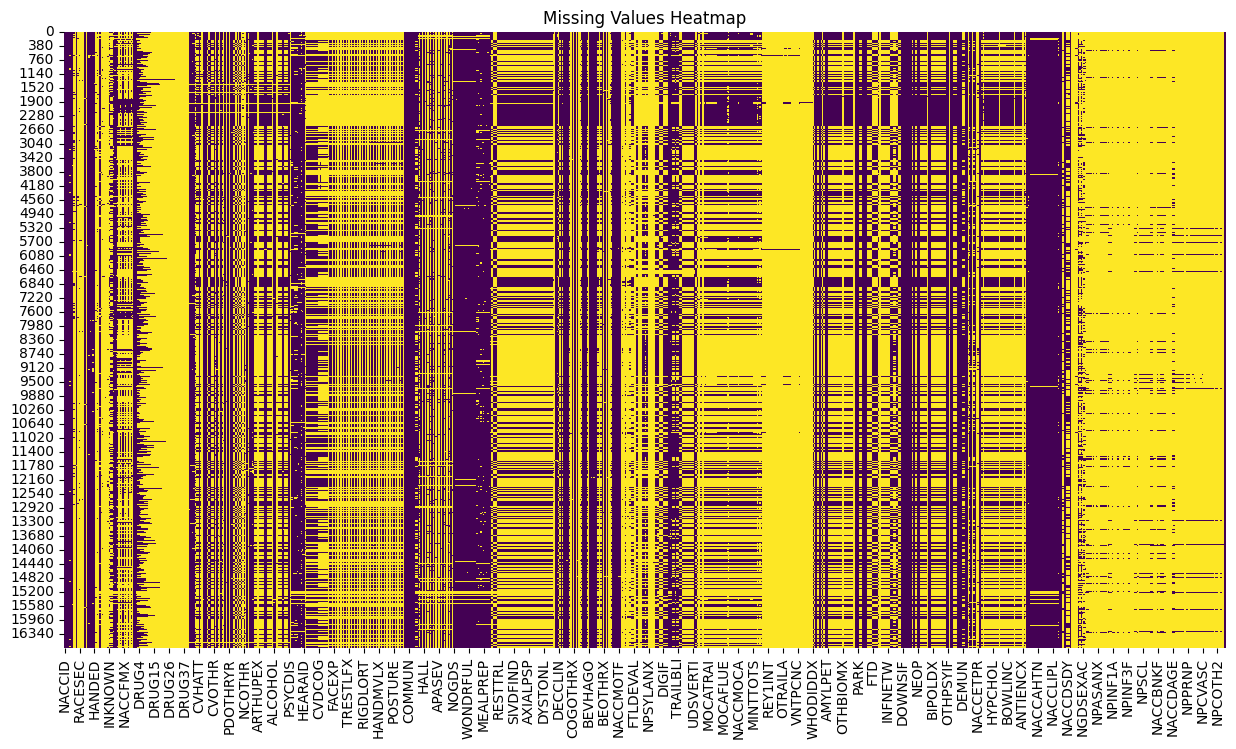

In [11]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_raw.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [12]:
len(nacc_raw.columns.tolist())

854

In [13]:
nan_pecentages_per_column = nacc_raw.isna().sum() / len(nacc_raw) * 100

In [14]:
significant_nan_num_columns = nan_pecentages_per_column[nan_pecentages_per_column > 80].index.tolist()
print(f"Columns with 80%+ number of missing values: {len(significant_nan_num_columns)}")

Columns with 80%+ number of missing values: 301


In [15]:
insignificant_nan_num_columns = nan_pecentages_per_column[nan_pecentages_per_column < 20].index.tolist()
print(f"Columns with < 20% number of missing values: {len(insignificant_nan_num_columns)}")

Columns with < 20% number of missing values: 209


In [16]:
average_nan_nacc = nacc_raw.drop(columns=significant_nan_num_columns + insignificant_nan_num_columns)
len(average_nan_nacc.columns.tolist())

344

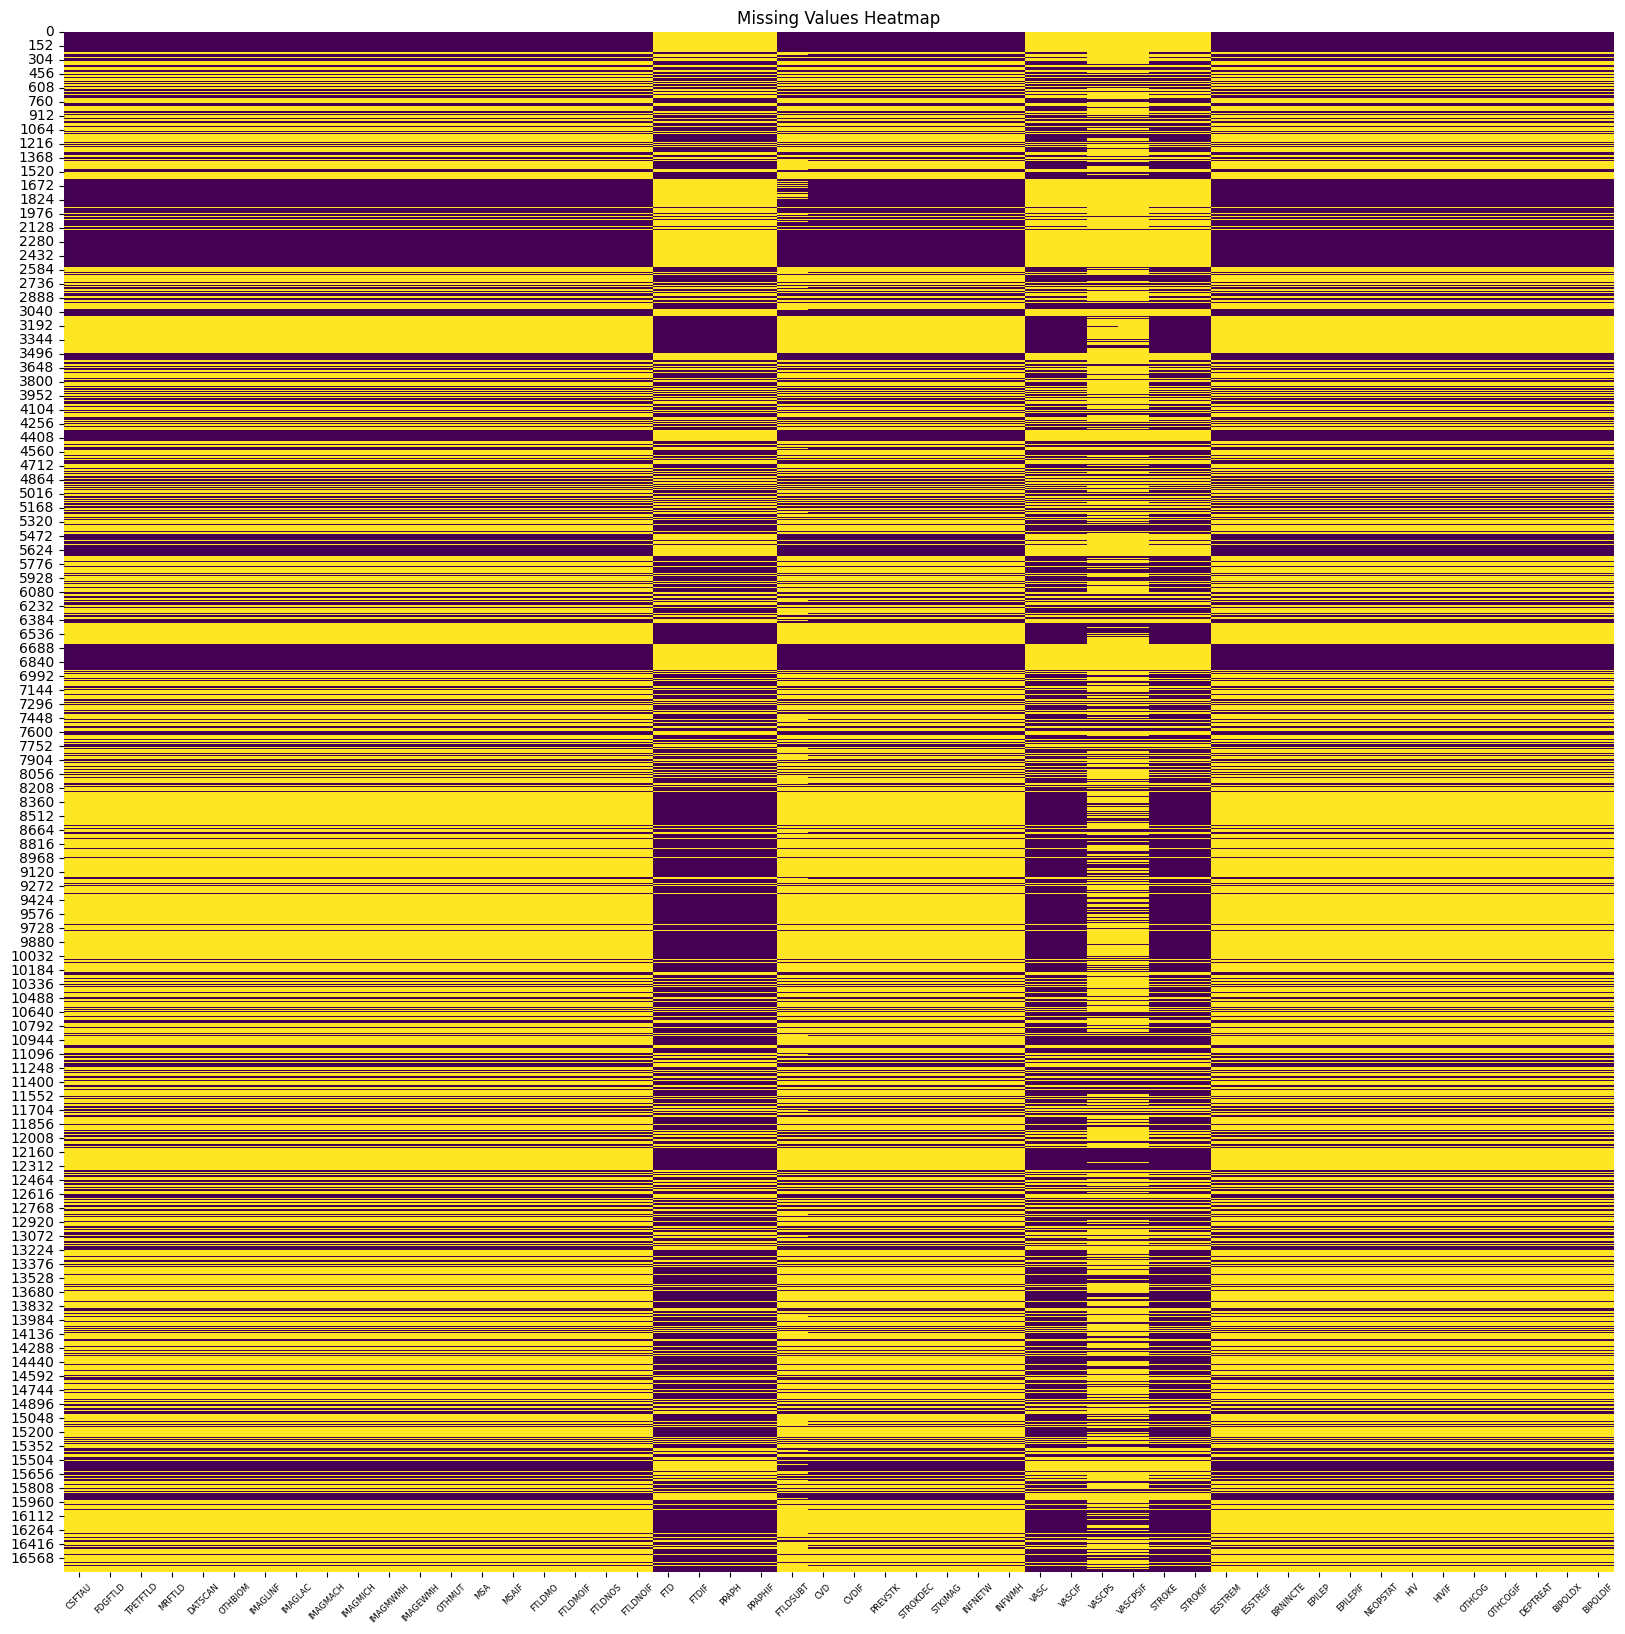

In [17]:
plt.figure(figsize=(20, 20))
sns.heatmap(average_nan_nacc.iloc[:, -100:-50].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

In [18]:
cleaned_average_nan_nacc = average_nan_nacc.drop(columns=['VASCPS', "VASCPSIF", 'FTLDSUBT', 'MOCARECC', 'NACCMOCA', 'CRAFTDTI', 'CRAFTCUE', 'MINTTOTS', 'MINTTOTW', 'MINTSCNC', 'MINTPCNC', 'MINTSCNG', 'MINTSCNC', 'MINTPCNG'])

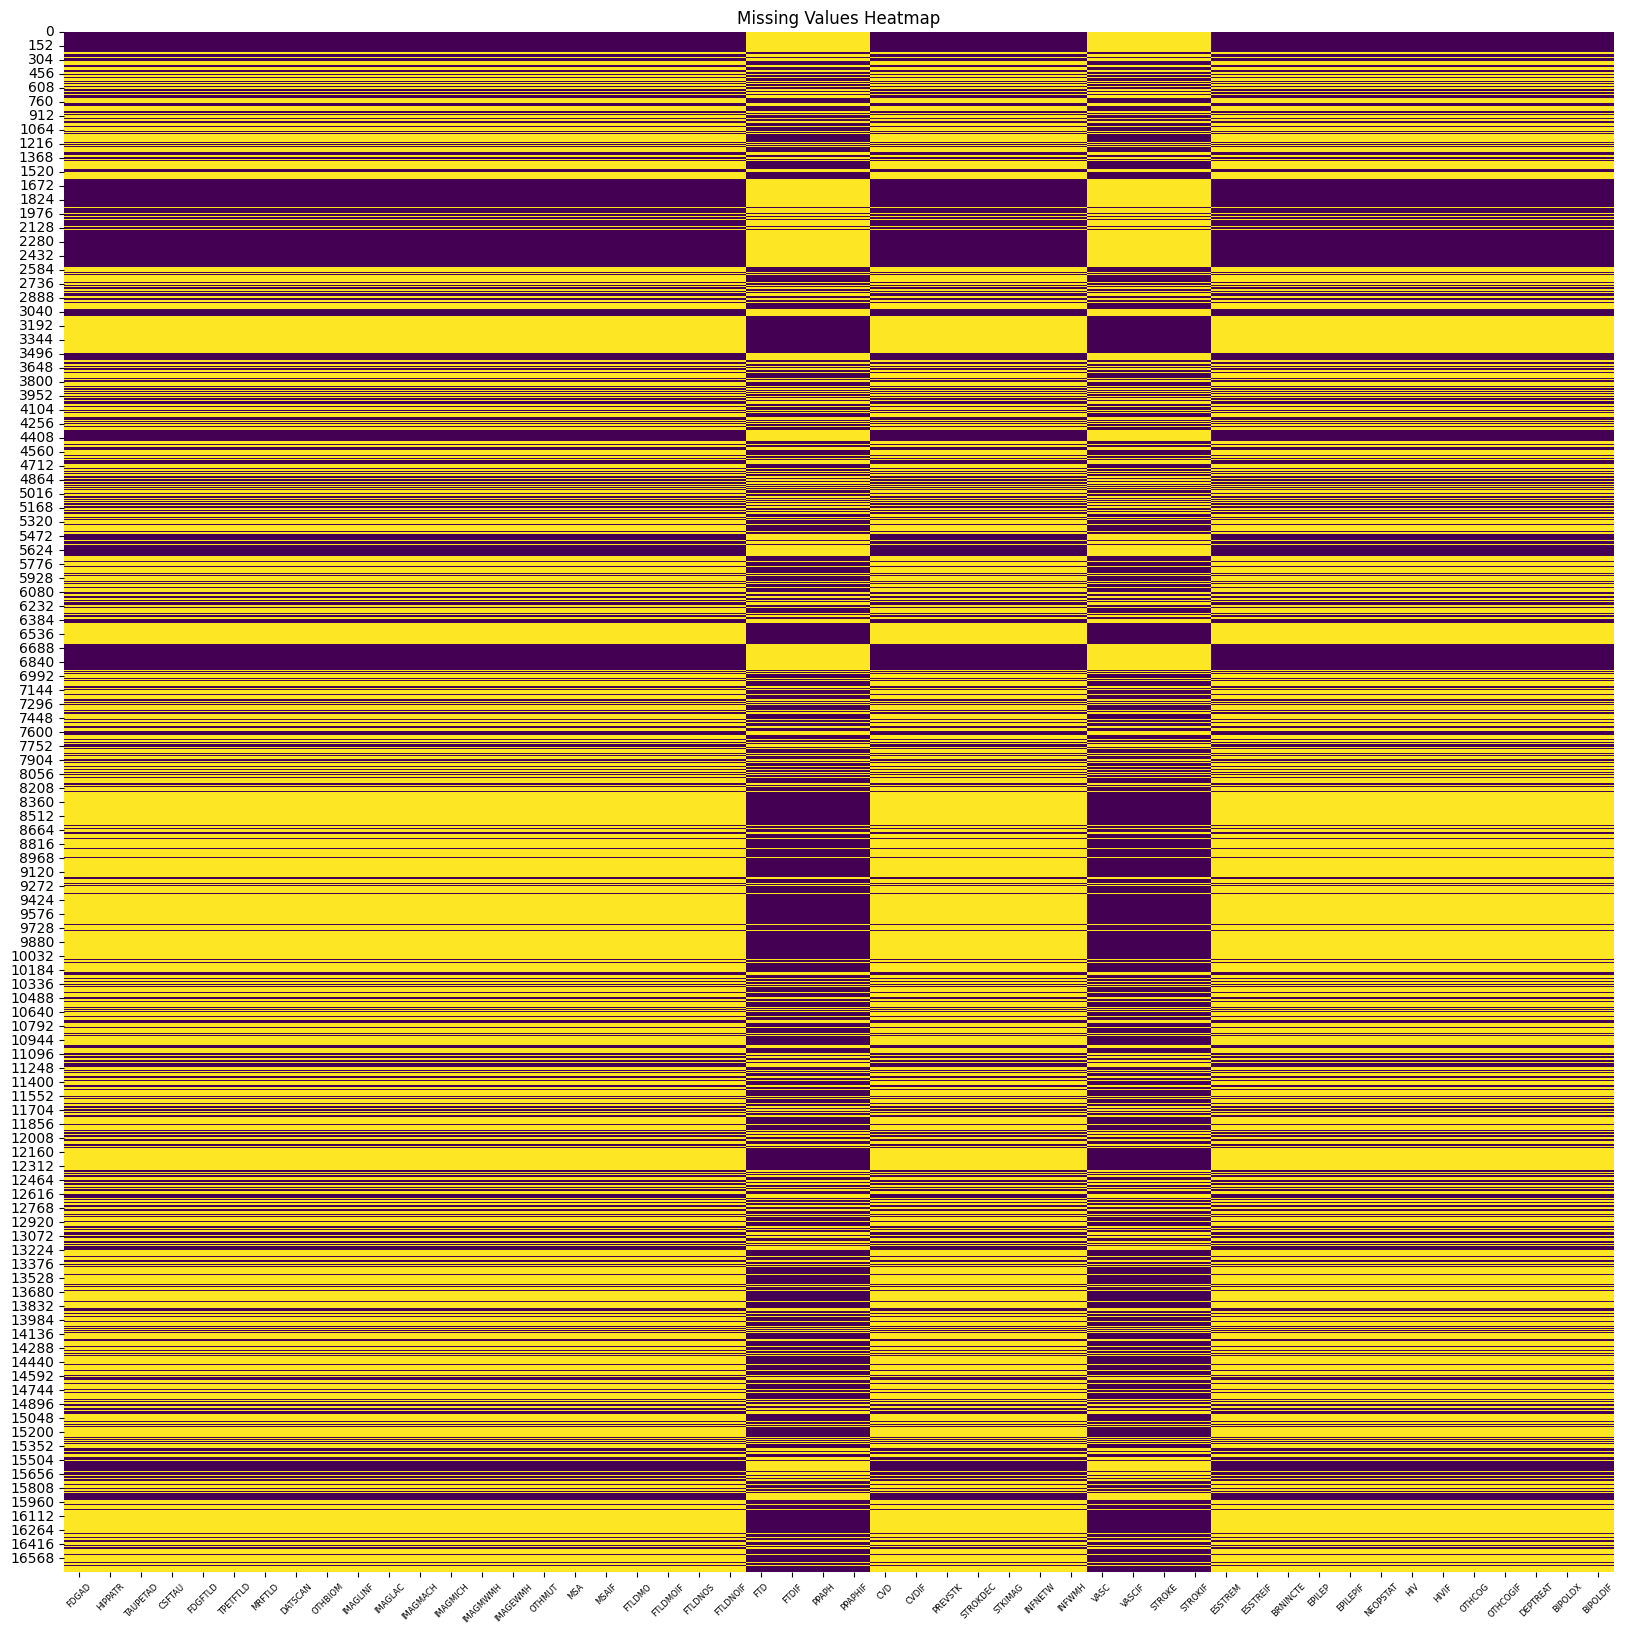

In [19]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc.iloc[:, -100:-50].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

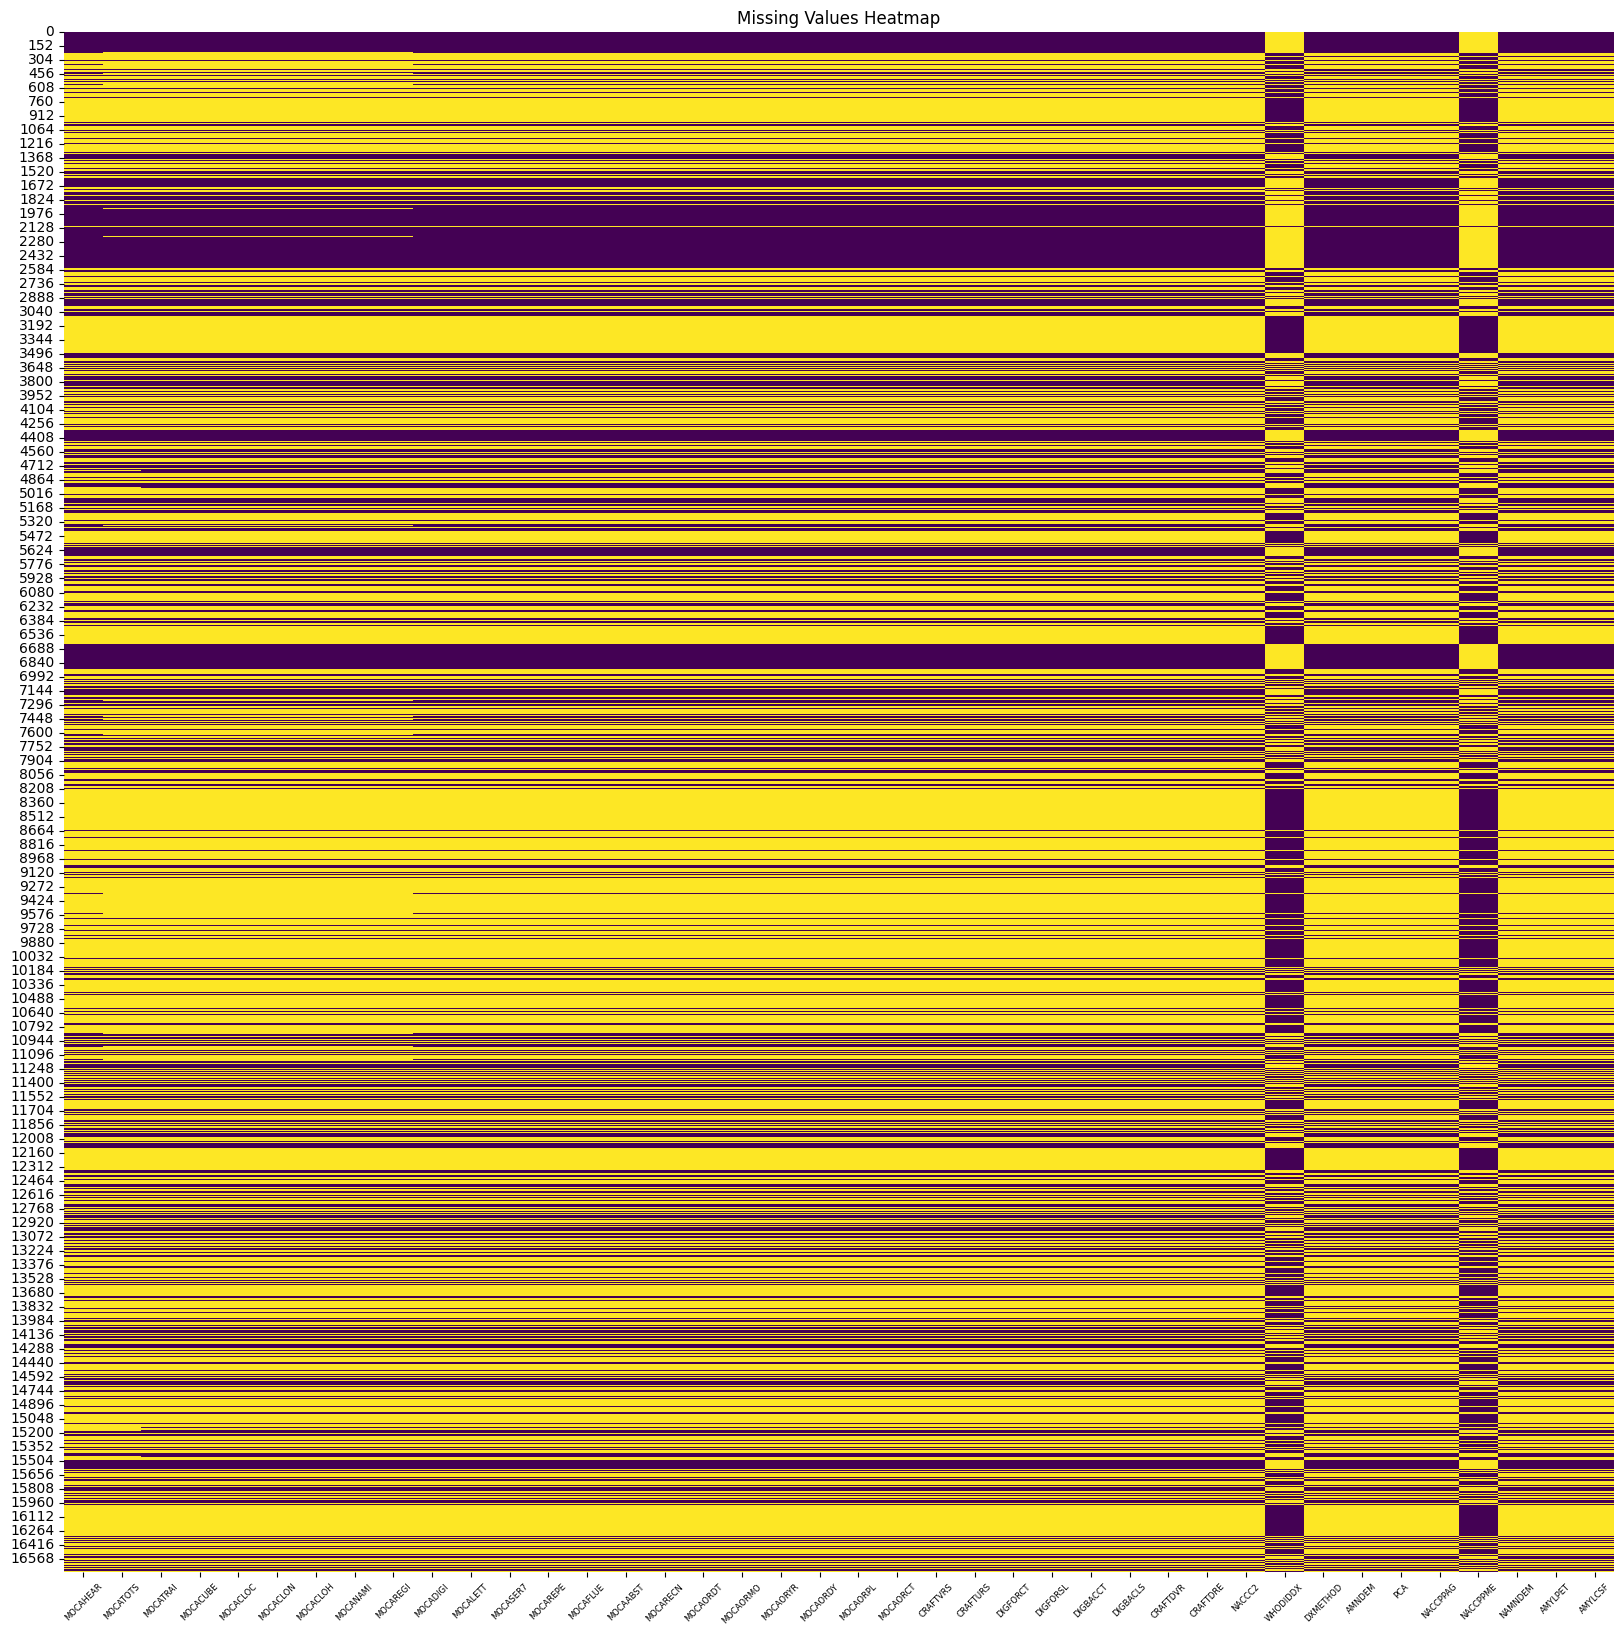

In [20]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc.iloc[:, -140:-100].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

In [21]:
# 'AMYLCSF', 'CSFTAU', 'FDGFTLD' - these biomarkers are often associated with AD which could be useful for the detection MCI
# I noticed that, there is a patter in the missigness of values and wanted to create a subdataset with these values and others to detect probably the dependency
# to possibly recover the data
cleaned_average_nan_nacc.iloc[:, -130:-50].columns

Index(['MOCALETT', 'MOCASER7', 'MOCAREPE', 'MOCAFLUE', 'MOCAABST', 'MOCARECN',
       'MOCAORDT', 'MOCAORMO', 'MOCAORYR', 'MOCAORDY', 'MOCAORPL', 'MOCAORCT',
       'CRAFTVRS', 'CRAFTURS', 'DIGFORCT', 'DIGFORSL', 'DIGBACCT', 'DIGBACLS',
       'CRAFTDVR', 'CRAFTDRE', 'NACCC2', 'WHODIDDX', 'DXMETHOD', 'AMNDEM',
       'PCA', 'NACCPPAG', 'NACCPPME', 'NAMNDEM', 'AMYLPET', 'AMYLCSF', 'FDGAD',
       'HIPPATR', 'TAUPETAD', 'CSFTAU', 'FDGFTLD', 'TPETFTLD', 'MRFTLD',
       'DATSCAN', 'OTHBIOM', 'IMAGLINF', 'IMAGLAC', 'IMAGMACH', 'IMAGMICH',
       'IMAGMWMH', 'IMAGEWMH', 'OTHMUT', 'MSA', 'MSAIF', 'FTLDMO', 'FTLDMOIF',
       'FTLDNOS', 'FTLDNOIF', 'FTD', 'FTDIF', 'PPAPH', 'PPAPHIF', 'CVD',
       'CVDIF', 'PREVSTK', 'STROKDEC', 'STKIMAG', 'INFNETW', 'INFWMH', 'VASC',
       'VASCIF', 'STROKE', 'STROKIF', 'ESSTREM', 'ESSTREIF', 'BRNINCTE',
       'EPILEP', 'EPILEPIF', 'NEOPSTAT', 'HIV', 'HIVIF', 'OTHCOG', 'OTHCOGIF',
       'DEPTREAT', 'BIPOLDX', 'BIPOLDIF'],
      dtype='object')

In [22]:
cleaned_average_nan_nacc = cleaned_average_nan_nacc.iloc[:, -130:-50]

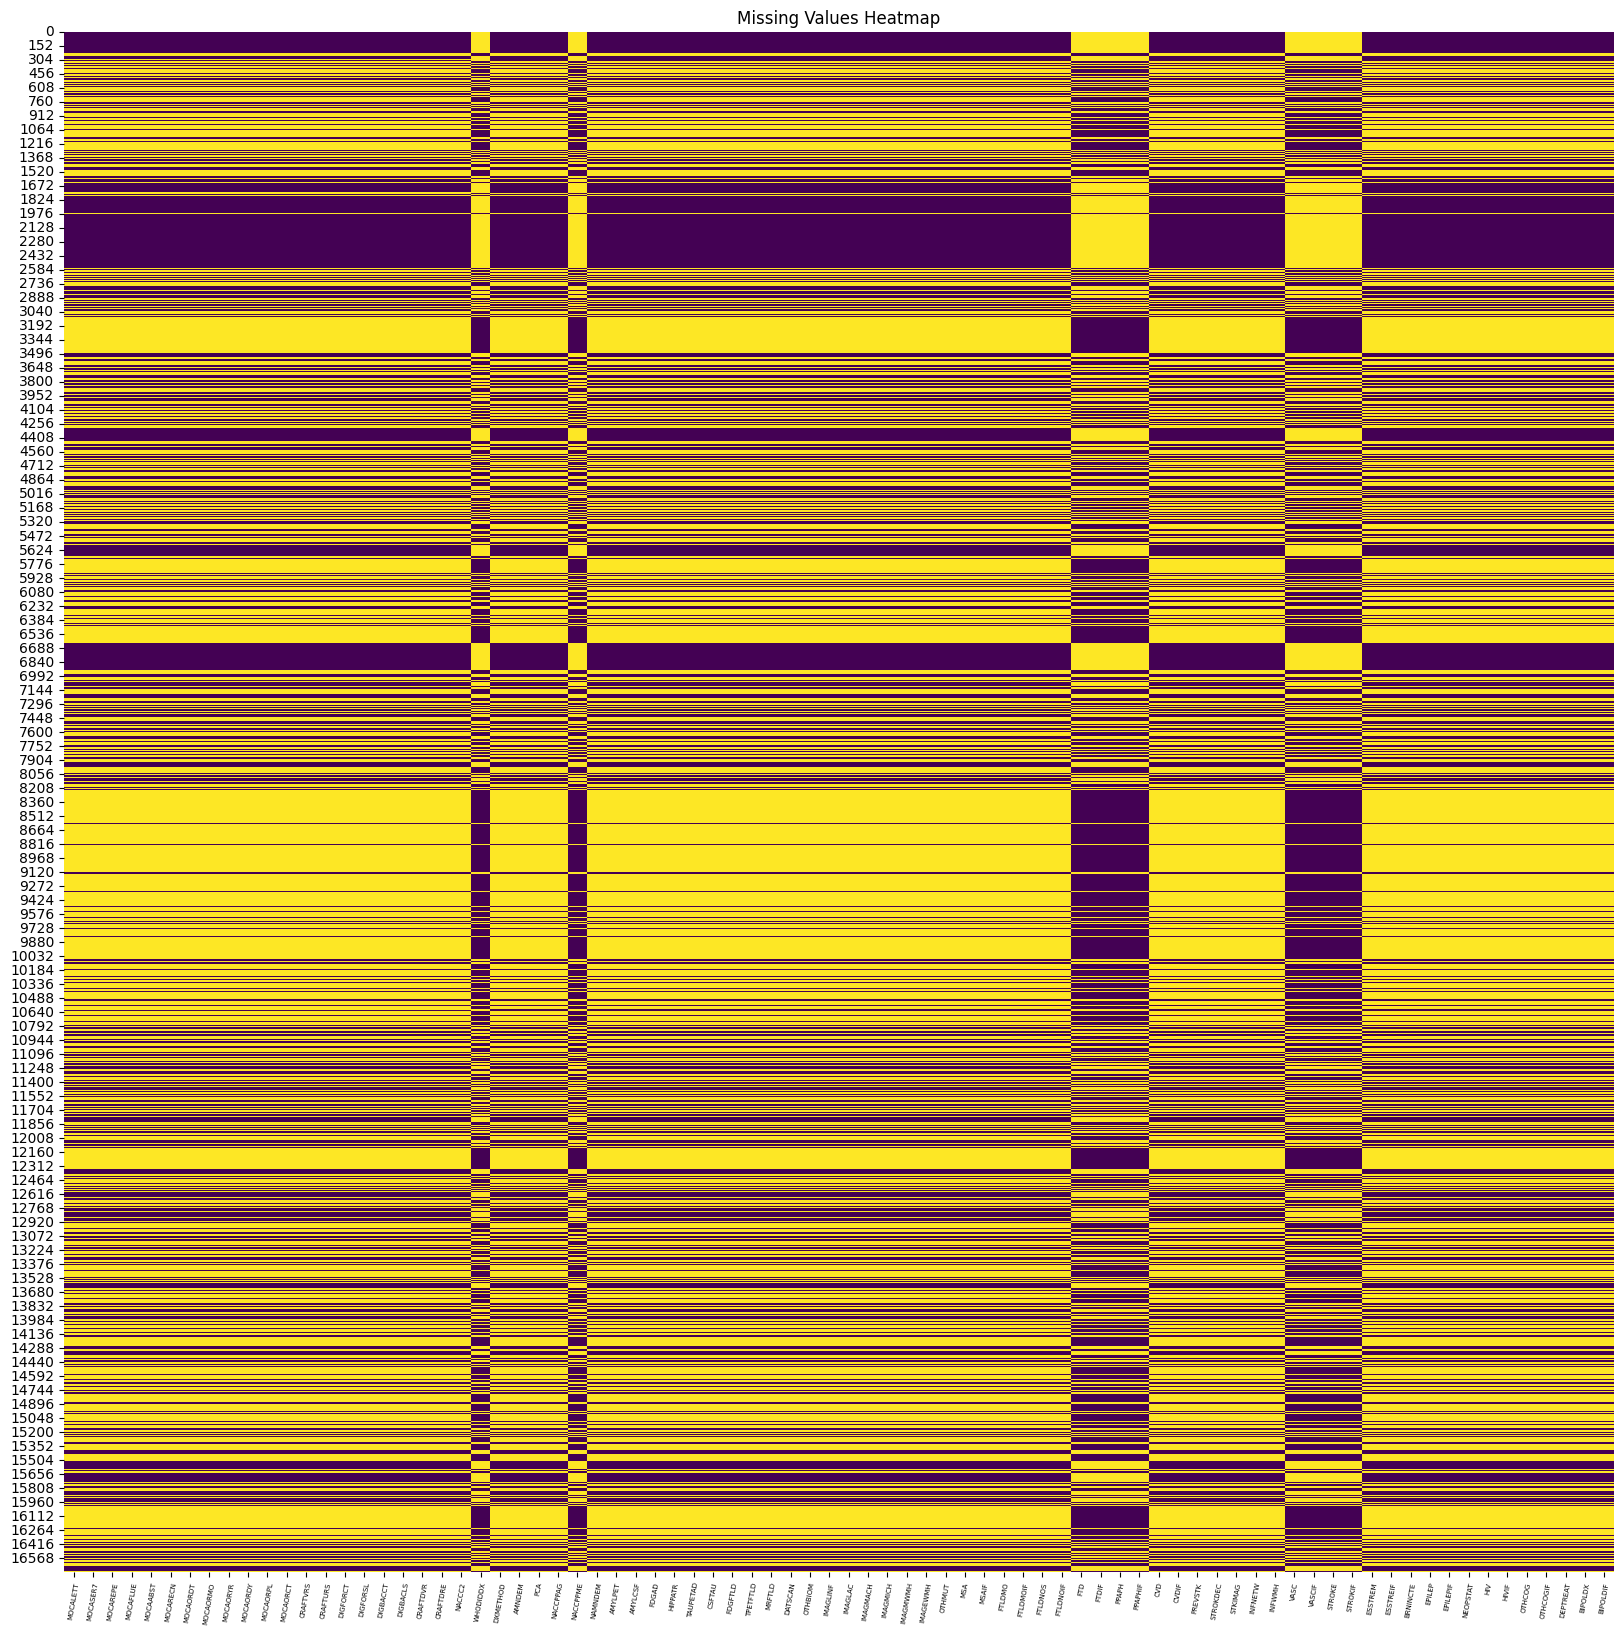

In [23]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc.isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

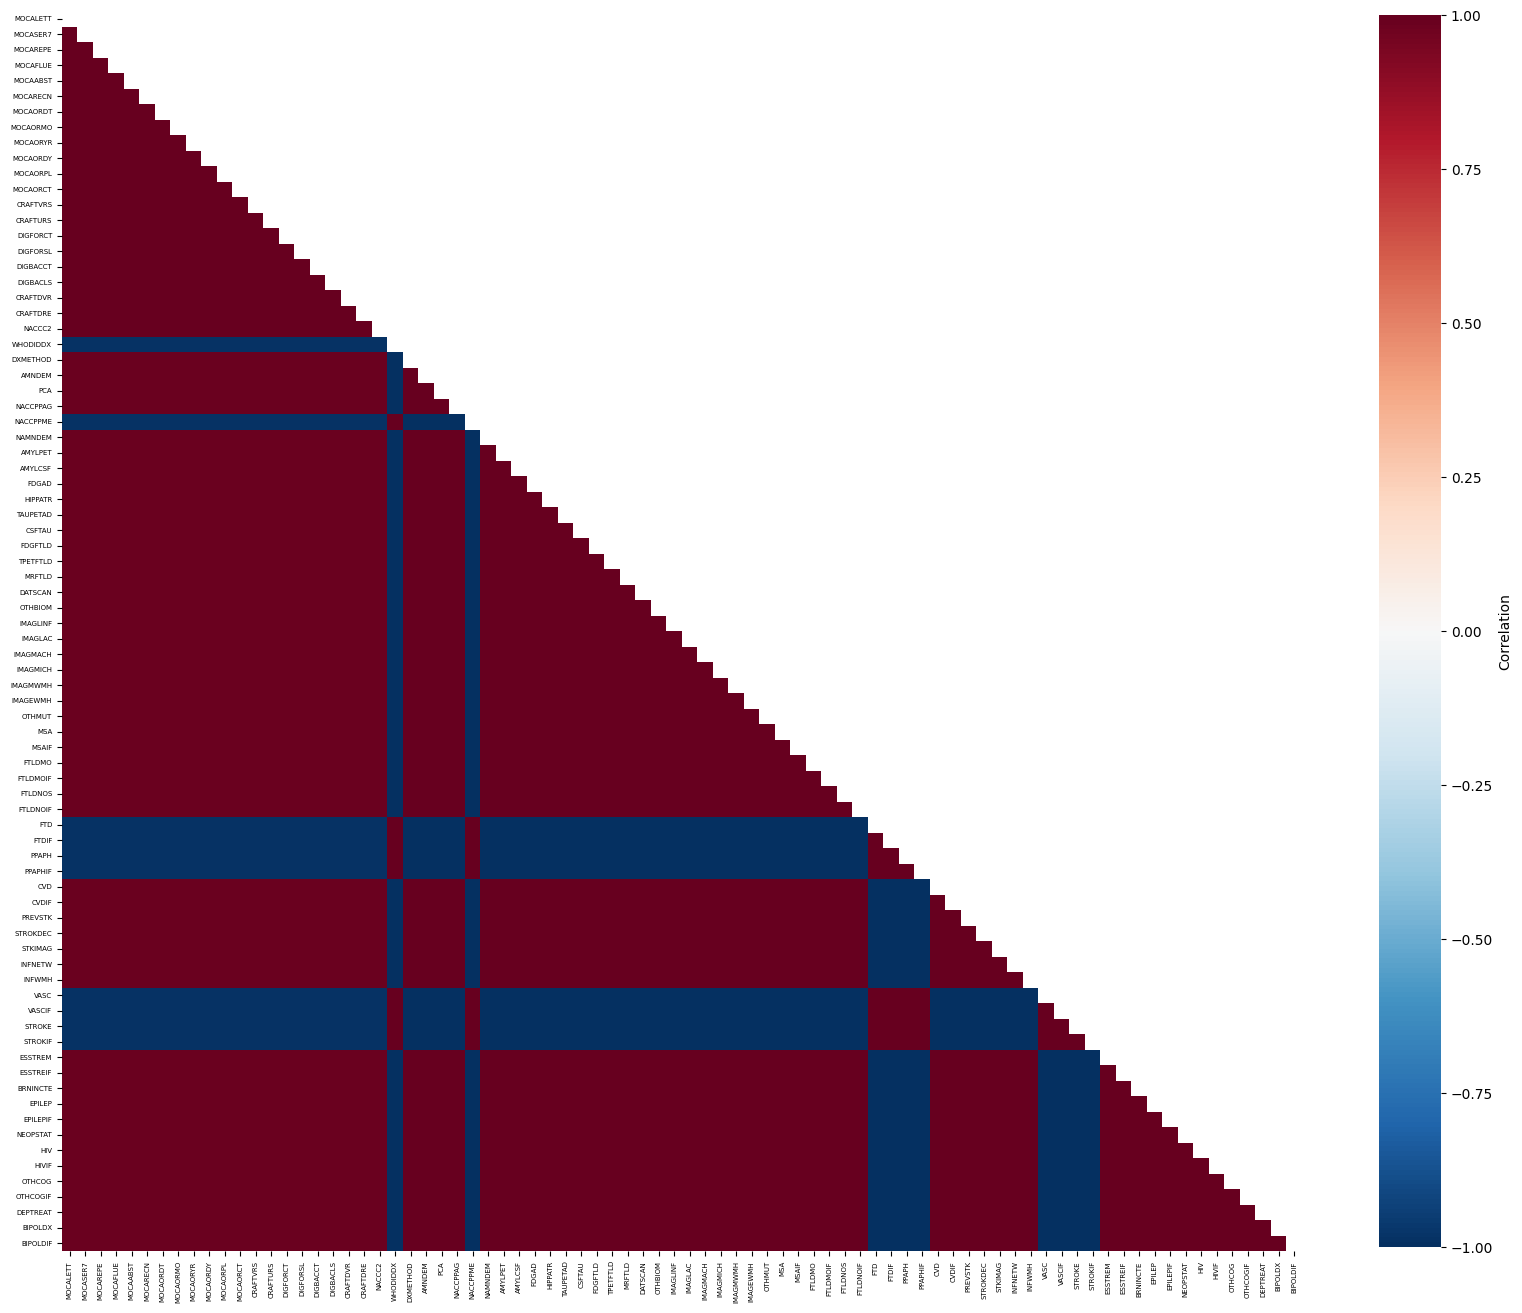

In [24]:
nan_corr = cleaned_average_nan_nacc.isnull().corr()

plt.figure(figsize=(20, 20))
mask = np.triu(np.ones_like(nan_corr, dtype=bool))
sns.heatmap(nan_corr, mask=mask, cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.show()

In [25]:
cleaned_avg_nacc_corr = cleaned_average_nan_nacc.isnull().corr()
the_same_pattern_df = cleaned_avg_nacc_corr['AMYLCSF'][cleaned_avg_nacc_corr['AMYLCSF'] >= 0.99999]
the_opposite_pattern_df = cleaned_avg_nacc_corr['AMYLCSF'][cleaned_avg_nacc_corr['AMYLCSF'] <= -0.99999]

group_1_columns = the_same_pattern_df.reset_index()['index'].tolist()
group_2_columns = the_opposite_pattern_df.reset_index()['index'].tolist()

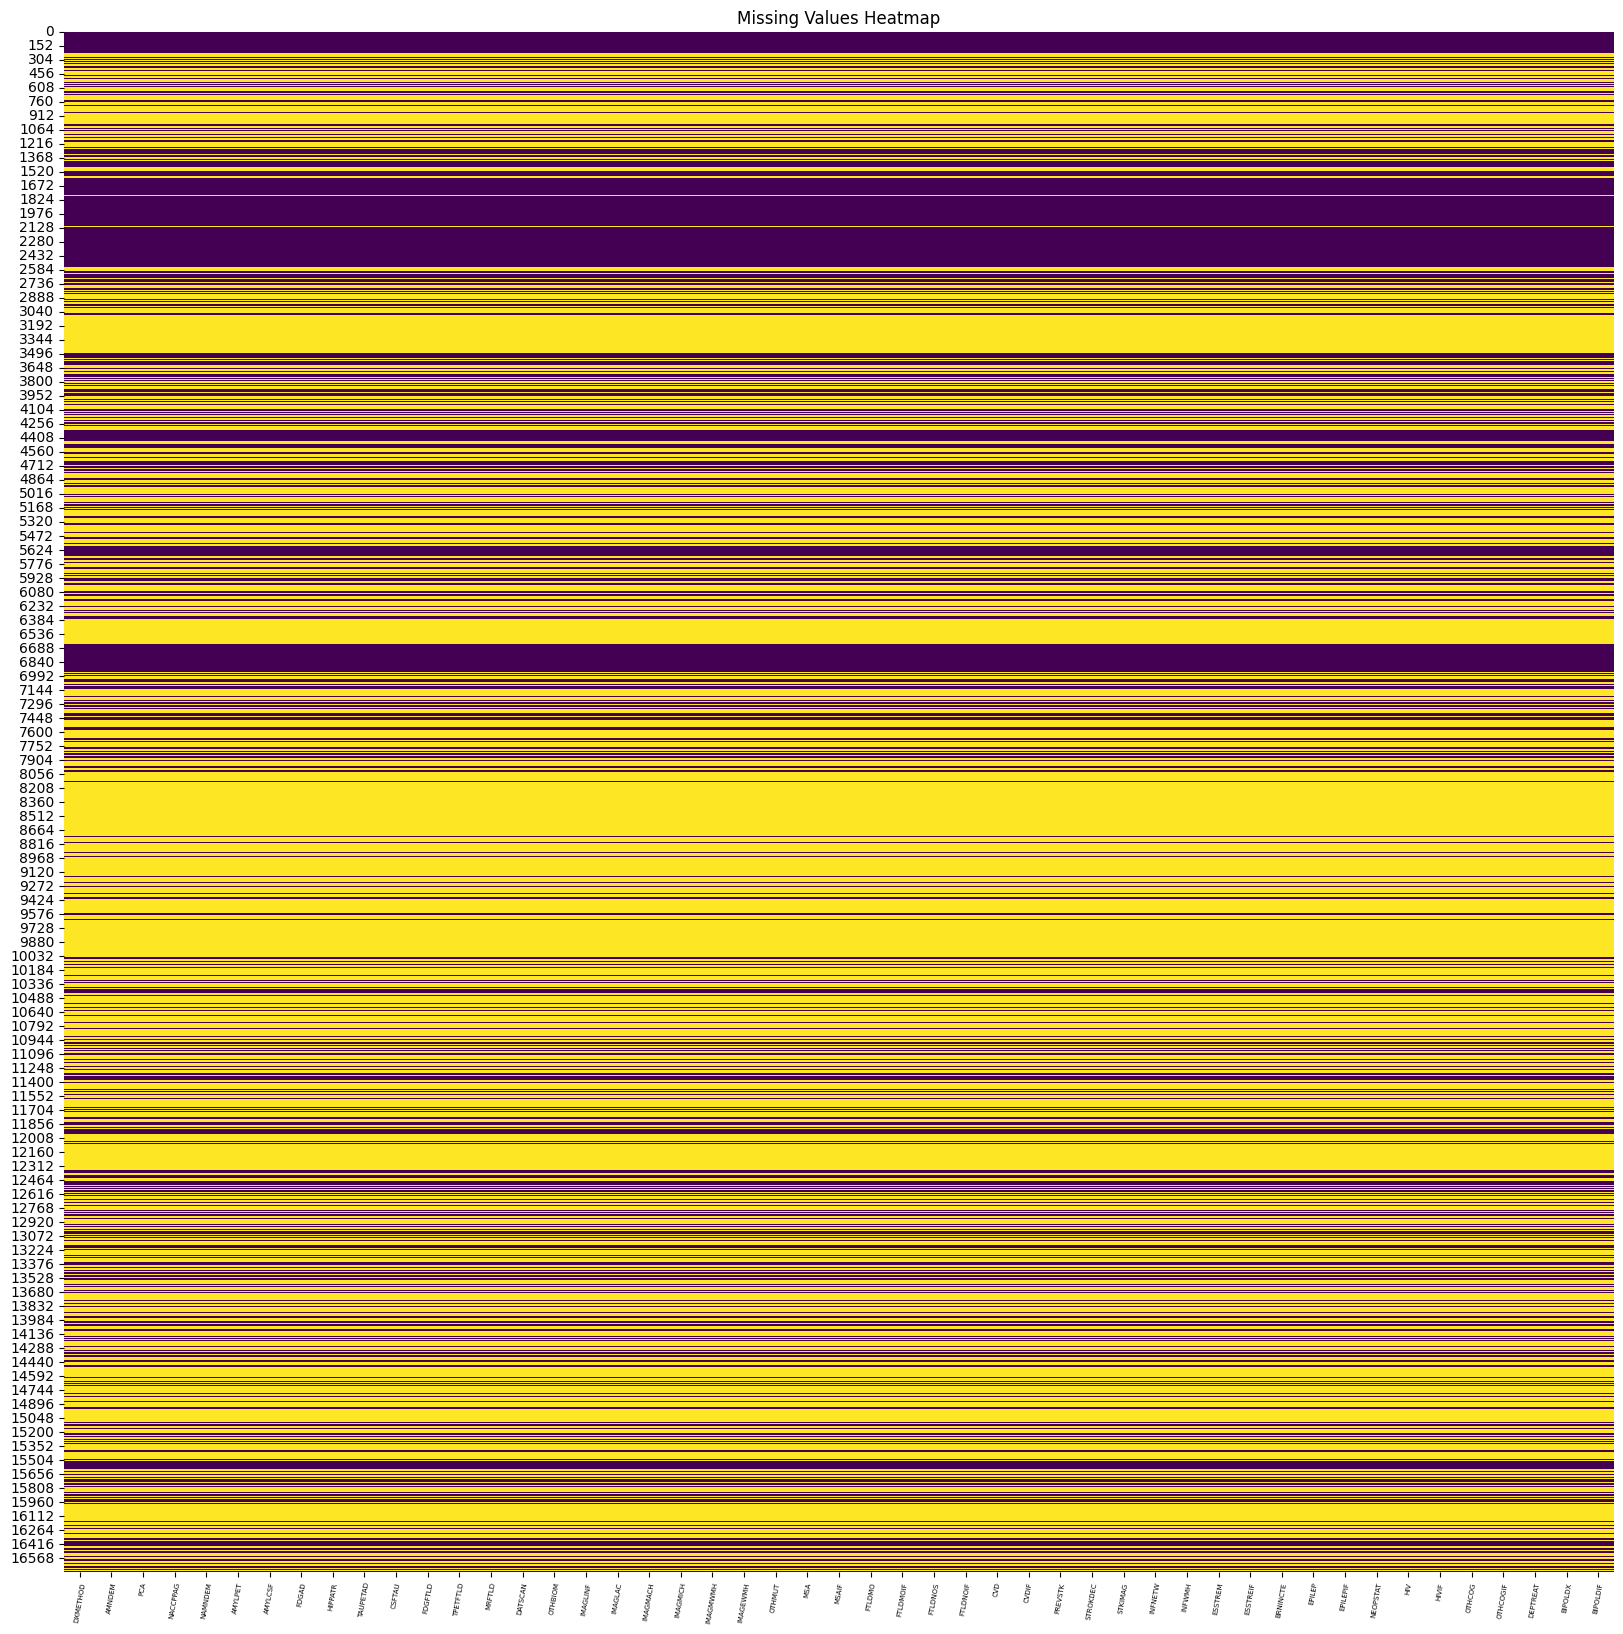

In [26]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc[group_1_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

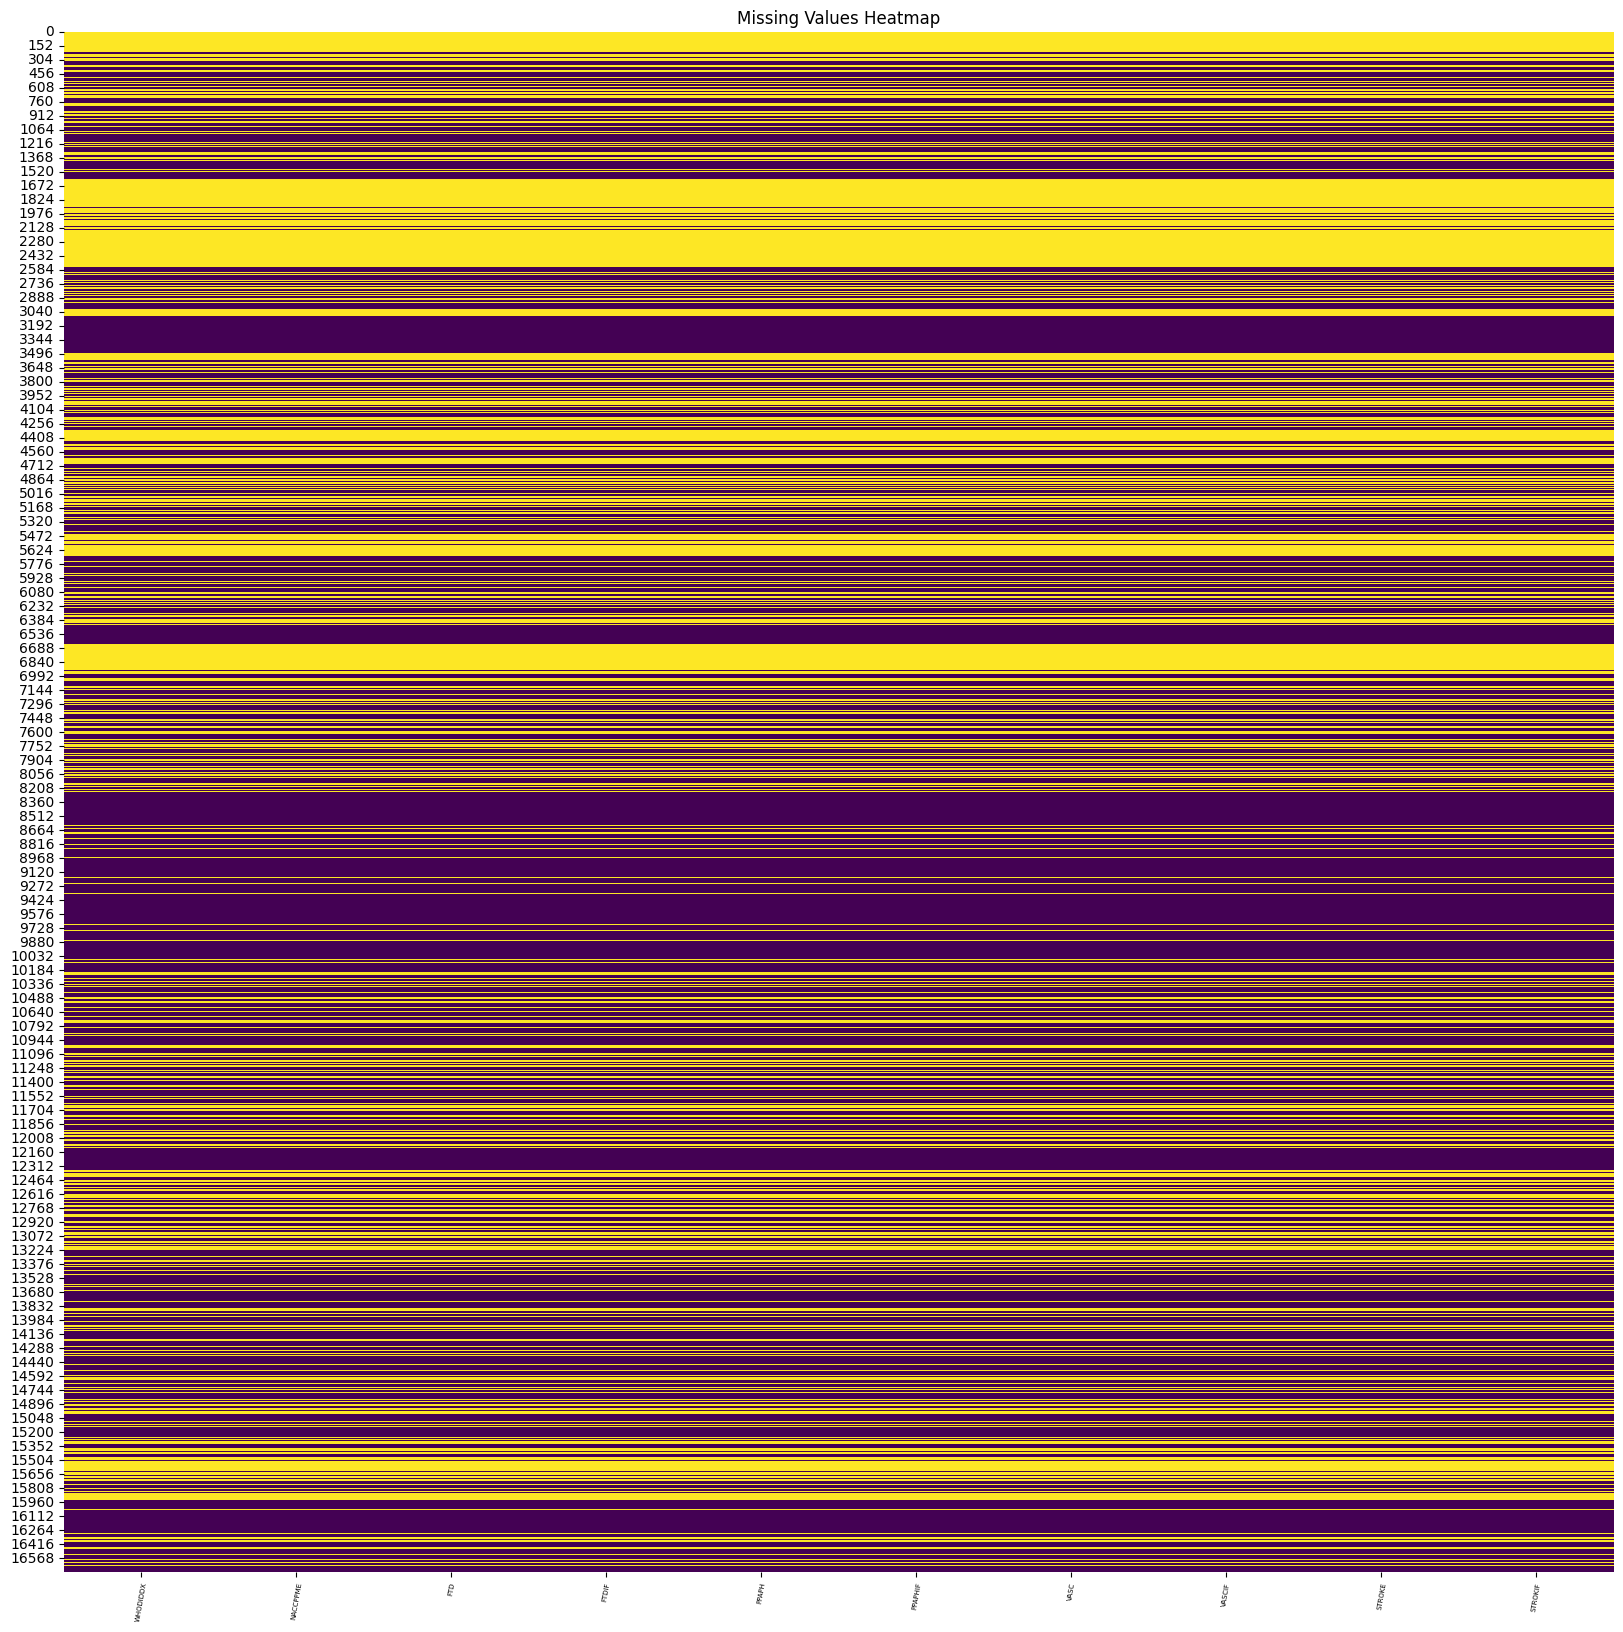

In [27]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc[group_2_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

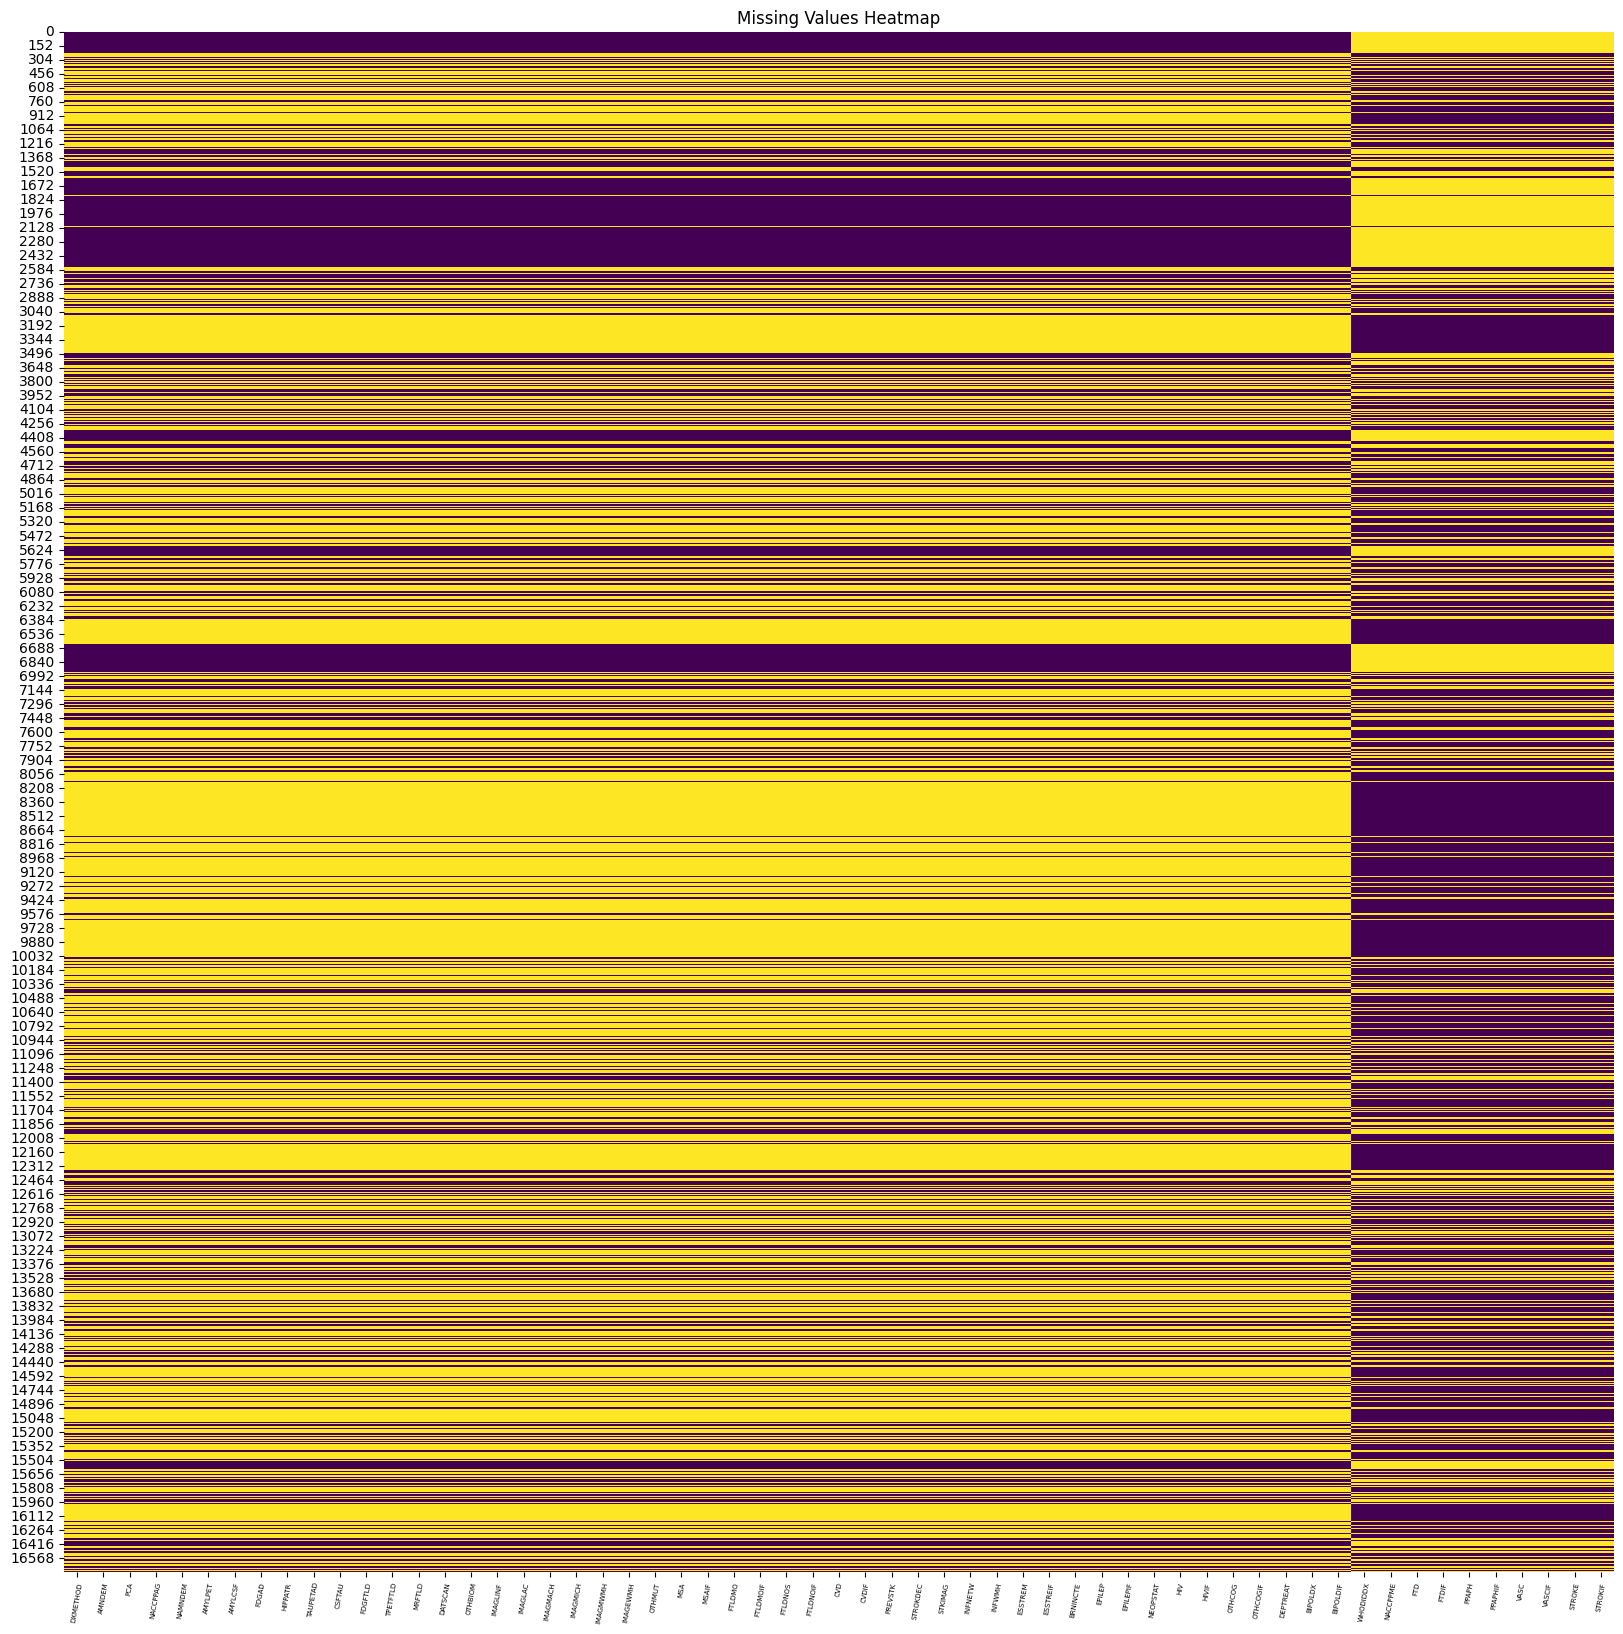

In [28]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_average_nan_nacc[group_1_columns + group_2_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

In [29]:
len(group_1_columns), len(group_2_columns)

(49, 10)

In [30]:
len(group_1_columns) / len(nacc_raw.columns) * 100, len(group_2_columns) / len(nacc_raw.columns) * 100

(5.737704918032787, 1.1709601873536302)

In [31]:
columns_to_continue = insignificant_nan_num_columns + group_1_columns + group_2_columns
len(columns_to_continue)

268

In [32]:
nacc_df = nacc_raw.copy()[columns_to_continue]
len(nacc_df.columns.tolist())

268

In [33]:
nacc_df["group"] = np.where(nacc_df['AMYLCSF'].isna(), 2, 1)
nacc_df.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,RACE,PRIMLANG,EDUC,...,NACCPPME,FTD,FTDIF,PPAPH,PPAPHIF,VASC,VASCIF,STROKE,STROKIF,group
0,NACC004687,11,14,2022,2.0,1,1.0,1.0,1.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,NACC021466,5,16,2023,2.0,2,1.0,1.0,1.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NACC023914,11,16,2023,1.0,1,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,NACC038914,8,11,2022,2.0,1,1.0,1.0,1.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,NACC048580,10,19,2023,2.0,2,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [34]:
nacc_df_grouped_copy = nacc_df.copy()
nacc_df_grouped_copy.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,RACE,PRIMLANG,EDUC,...,NACCPPME,FTD,FTDIF,PPAPH,PPAPHIF,VASC,VASCIF,STROKE,STROKIF,group
0,NACC004687,11,14,2022,2.0,1,1.0,1.0,1.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,NACC021466,5,16,2023,2.0,2,1.0,1.0,1.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NACC023914,11,16,2023,1.0,1,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,NACC038914,8,11,2022,2.0,1,1.0,1.0,1.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,NACC048580,10,19,2023,2.0,2,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


## Analyse data types and categorical values

In [35]:
nacc_raw.select_dtypes(include=['object', "string"]).columns

Index(['NACCID', 'HISPORX', 'RACEX', 'RACESECX', 'RACETERX', 'PRIMLANX',
       'INHISPOX', 'INRACEX', 'INRASECX', 'INRATERX',
       ...
       'NACCWRI2', 'NACCWRI3', 'NPFAUT1', 'NPFAUT2', 'NPFAUT3', 'NPFAUT4',
       'NPFHSPEC', 'NPOTH1X', 'NPOTH2X', 'NPOTH3X'],
      dtype='object', length=134)

In [36]:
len(nacc_raw.select_dtypes(include=['number']).columns.tolist())

720

In [37]:
columns_type = []

for col in nacc_raw.columns:
  columns_type.append(nacc_raw[col].dtype)

list(set(columns_type))

[dtype('float64'), dtype('int64'), dtype('O')]

It is seen the there is only one column represented as categorical data, which is the NACCID. We do not need to convert categorical data

In [38]:
no_variance_columns = []

for col in nacc_df.columns:
  col_unique = nacc_df[col].unique()
  if len(col_unique) == 1:
    print(f"{col} has only 1 unique value: {col_unique}")
    no_variance_columns.append(col)
  if len(col_unique) == 2:
    has_nan = pd.isna(col_unique).any()
    if has_nan:
      print(f"{col} has only 1 unique value and NaN: {col_unique}")
      no_variance_columns.append(col)

HUNT has only 1 unique value: [0]
PRION has only 1 unique value: [0]
NACCPPAG has only 1 unique value and NaN: [ 8. nan]
NAMNDEM has only 1 unique value and NaN: [ 8. nan]


In [39]:
nacc_df.drop(columns=no_variance_columns, inplace=True)

## Analyse imbalance

In [40]:
nacc_df.groupby("SEX")['SEX'].agg("count")

SEX
1     5909
2    10807
Name: SEX, dtype: int64

In [41]:
nacc_df.groupby("SEX")['SEX'].agg("count") / nacc_df.shape[0] * 100

SEX
1    35.349366
2    64.650634
Name: SEX, dtype: float64

In [42]:
balance = []
for col in nacc_df.columns:
  if len(nacc_df[col].unique()) == 2:
    balance.append({"column": col, "percentages": nacc_df.groupby(col)[col].agg("count") / nacc_df.shape[0], "vals": nacc_df.groupby(col)[col].agg("count")})

len(balance)

30

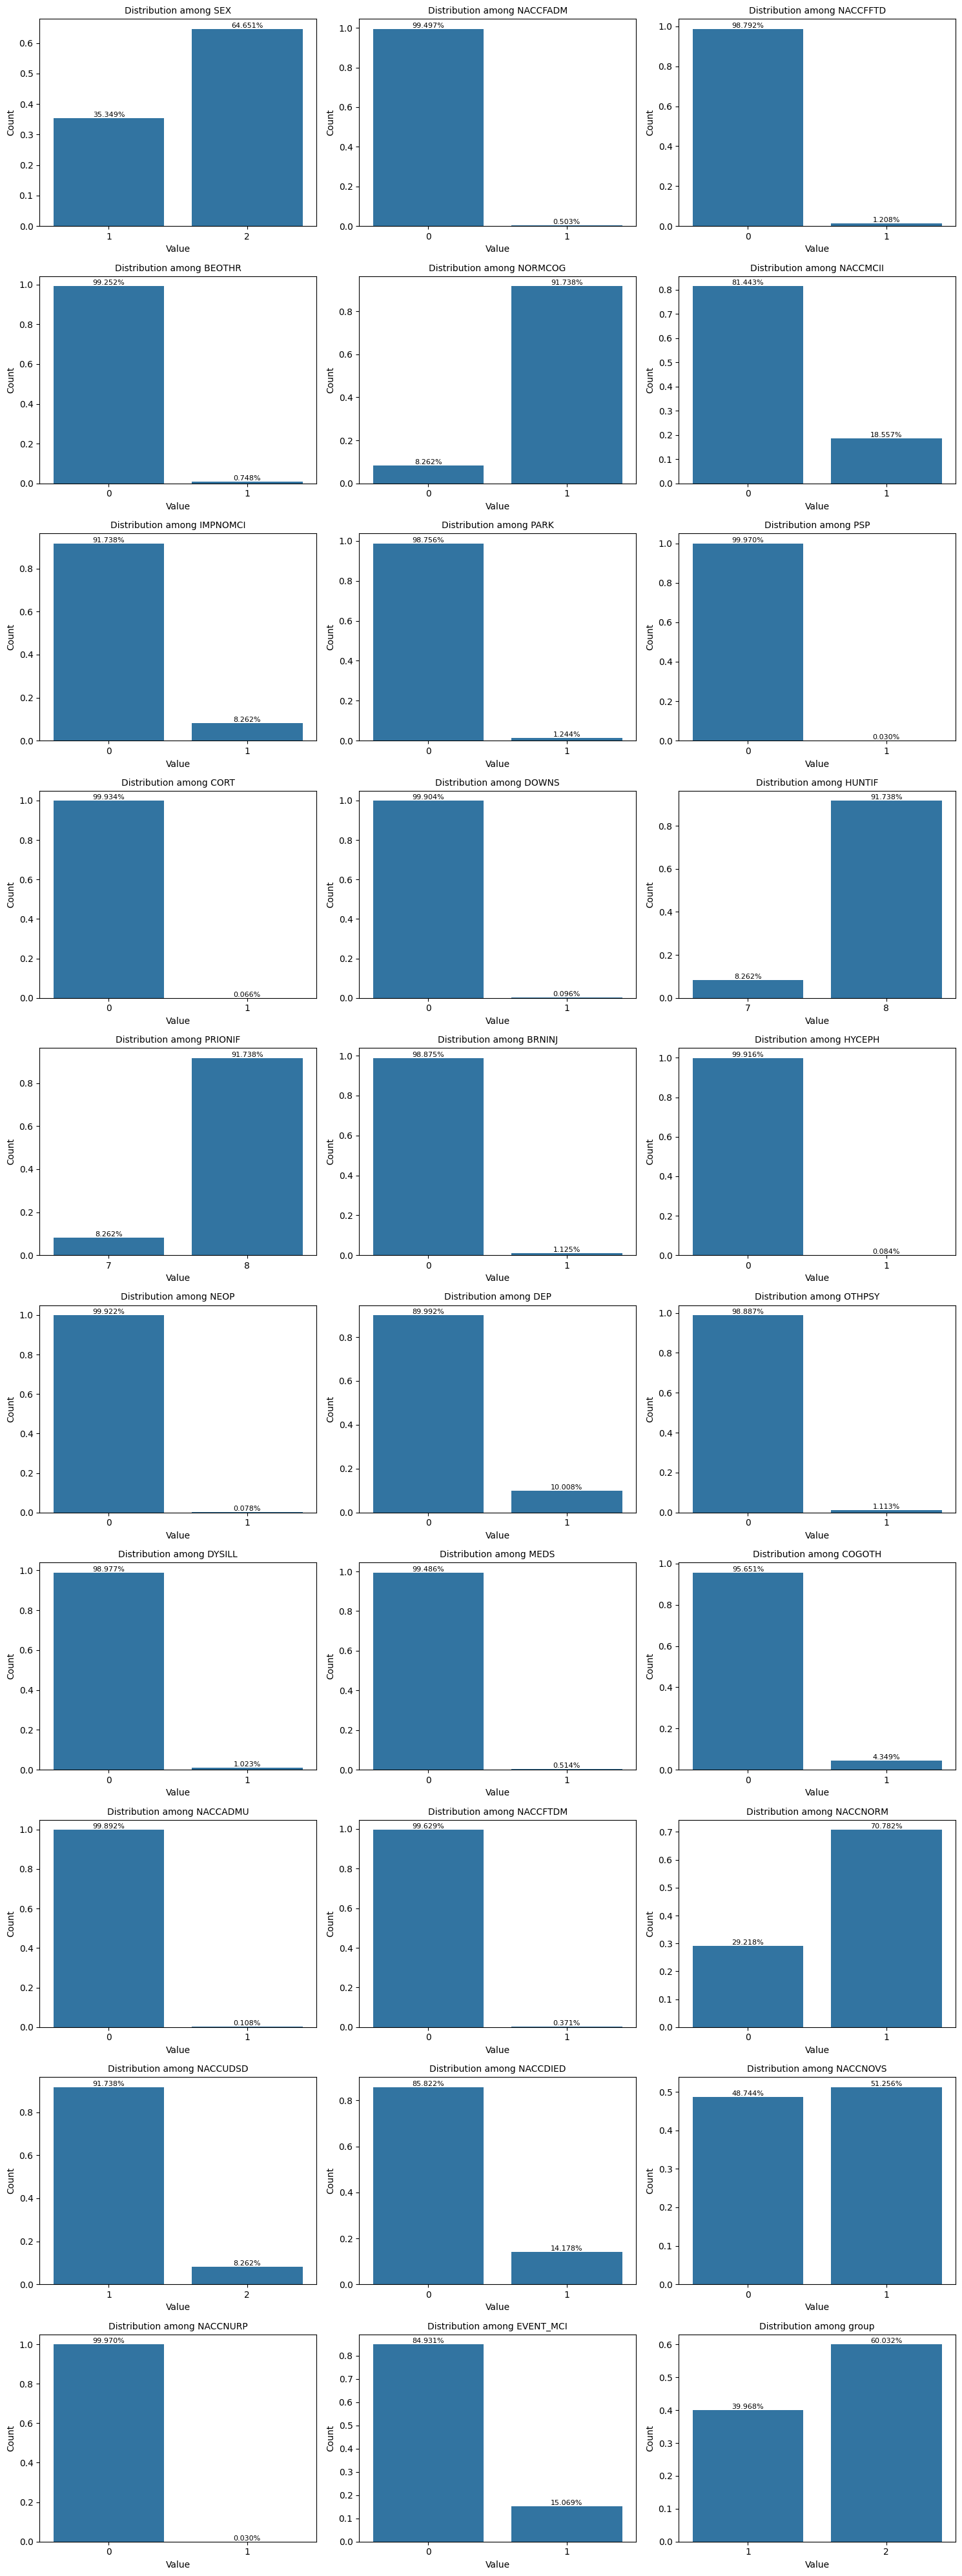

In [43]:
import math

n_cols = 3
n_rows = math.ceil(len(balance) / n_cols)

fix, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, item in enumerate(balance):
  ax = axes[i]
  df = item["percentages"]

  sns.barplot(df, ax=ax)
  ax.set_title(f"Distribution among {item["column"]}", fontsize=10)
  ax.set_xlabel("Value")
  ax.set_ylabel("Count")

  ax.bar_label(
        ax.containers[0],
        labels=[f"{v * 100:.3f}%" for v in df.values],
        fontsize=8,
    )


plt.tight_layout()

In [44]:
low_variance_columns = []

for bal in balance:
  values = bal["percentages"].values
  if values[0] < 0.009 or values[1] < 0.009:
    print(f"{bal["column"]} has low variance {values} {bal['vals'].values}")

NACCFADM has low variance [0.99497487 0.00502513] [16632    84]
BEOTHR has low variance [0.99252213 0.00747787] [16591   125]
PSP has low variance [9.99700885e-01 2.99114621e-04] [16711     5]
CORT has low variance [9.99341948e-01 6.58052166e-04] [16705    11]
DOWNS has low variance [9.99042833e-01 9.57166786e-04] [16700    16]
HYCEPH has low variance [9.99162479e-01 8.37520938e-04] [16702    14]
NEOP has low variance [9.99222302e-01 7.77698014e-04] [16703    13]
MEDS has low variance [0.99485523 0.00514477] [16630    86]
NACCADMU has low variance [0.99892319 0.00107681] [16698    18]
NACCFTDM has low variance [0.99629098 0.00370902] [16654    62]
NACCNURP has low variance [9.99700885e-01 2.99114621e-04] [16711     5]


In [45]:
nacc_df.drop(columns=low_variance_columns, inplace=True)

In [46]:
len(nacc_df.columns.tolist())

265

### Drop useless columns or columns that are representations of MCI

In [47]:
nacc_df.drop(columns=['NACCID'], inplace=True)

In [48]:
nacc_df.drop(columns=['NACCMCII', 'NACCNORM', 'COGSTAT', 'VISITDAY', 'VISITYR', 'VISITMO'], inplace=True)

In [49]:
nacc_df.shape

(16716, 258)

In [50]:
# nacc_nan_percentages = nacc_df.isnull().sum() / nacc_df.shape[0] * 100
# nacc_nan_percentages.reset_index()
# columns_with_small_amount_of_nan = nacc_nan_percentages[nacc_nan_percentages < 20].index.tolist()
# nacc_df.dropna(subset=columns_with_small_amount_of_nan, inplace=True)

In [51]:
nacc_group_1 = nacc_df[nacc_df['group'] == 1]
nacc_group_2 = nacc_df[nacc_df['group'] == 2]
nacc_group_2.head()

,NACCREFR,SEX,HISPANIC,RACE,PRIMLANG,EDUC,MARISTAT,NACCLIVS,INDEPEND,RESIDENC,...,NACCPPME,FTD,FTDIF,PPAPH,PPAPHIF,VASC,VASCIF,STROKE,STROKIF,group
216,NaN,1,0.0,1.0,1.0,17.0,1.0,2.0,1.0,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,8.0,2
218,8.0,2,0.0,5.0,4.0,19.0,1.0,2.0,1.0,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,8.0,2
222,1.0,2,0.0,5.0,3.0,15.0,NaN,3.0,1.0,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,8.0,2
223,8.0,1,0.0,5.0,3.0,20.0,1.0,2.0,1.0,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,8.0,2
224,8.0,2,0.0,1.0,1.0,20.0,2.0,1.0,1.0,1.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,8.0,2


In [52]:
print(f"Percentage of records in the group1 {nacc_group_1.shape[0] / nacc_df.shape[0]}")

Percentage of records in the group1 0.3996769562096195


In [53]:
print(f"Percentage of records in the group2 {nacc_group_2.shape[0] / nacc_df.shape[0]}")

Percentage of records in the group2 0.6003230437903805


## Censoring rate

In [54]:
time_missed = nacc_df[nacc_df['TIME'].isna()]
time_missed.shape[0]

0

In [55]:
event_missed = nacc_df[nacc_df['EVENT_MCI'].isna()]
event_missed.shape[0]

0

In [56]:
wrong_time = nacc_df[nacc_df['TIME'] < 0]
wrong_time.shape[0]

0

In [57]:
wrong_event = nacc_df[~nacc_df['EVENT_MCI'].isin([1,0])]
wrong_event.shape[0]

0

In [58]:
censored_data = nacc_df[nacc_df['EVENT_MCI'] == 0]

censoring_rate = censored_data.shape[0] / nacc_df.shape[0] * 100
print(f"Censoring rate {censoring_rate:.3f}%")

Censoring rate 84.931%


## Split and prepare dataset

In [59]:
cleaned_nacc = nacc_df.copy()

In [60]:
cleaned_nacc['group'].unique()

array([1, 2])

In [61]:
cleaned_nacc[cleaned_nacc['EVENT_MCI'] == 1].shape

(2519, 258)

In [62]:
train_data, test_data = model_selection.train_test_split(
    cleaned_nacc, test_size=0.2, random_state=55552, 
    stratify=cleaned_nacc['EVENT_MCI']
)

train_data, val_data = model_selection.train_test_split(
    train_data, test_size=0.2, random_state=55552,
    stratify=train_data['EVENT_MCI']
)

In [63]:
x_train = train_data.drop(columns=['TIME', 'EVENT_MCI'])
y_train = Surv.from_dataframe('EVENT_MCI', 'TIME', train_data)

In [64]:
def split_by_groups(x_data, y_data):
  x1_mask = x_data['group'] == 1
  x1_data = x_data[x1_mask].dropna(axis=1)
  y1_data = y_data[x1_mask]

  x2_mask = x_data['group'] == 2
  x2_data = x_data[x2_mask].dropna(axis=1)
  y2_data = y_data[x2_mask]

  return x1_data, y1_data, x2_data, y2_data

In [65]:
x1_train, y1_train, x2_train, y2_train = split_by_groups(x_train, y_train)

## Select features for the further analysis

### Random Survival Forest Feature selection

In [66]:
top_features_n_per_group = 20

[permutation_importance](https://scikit-survival.readthedocs.io/en/stable/user_guide/random-survival-forest.html)

In [67]:
from sklearn.inspection import permutation_importance

def select_top_features(x_data, y_data, n_estimators=15):
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        random_state=42,
        max_features='sqrt'
    )
    rsf.fit(x_data, y_data)

    importance = permutation_importance(rsf, x_data, y_data, n_repeats=8, random_state=42)

    feature_importance = pd.DataFrame(
        {
            k: importance[k]
            for k in (
                "importances_mean",
                "importances_std",
            )
        },
        index=x_data.columns
    )
    feature_importance["importances_mean_abs"] = np.abs(feature_importance['importances_mean'])

    return feature_importance.sort_values(by="importances_mean_abs", ascending=False)

In [68]:
rsf_feature_importance_1 = select_top_features(x1_train, y1_train)
rsf_feature_importance_1 = rsf_feature_importance_1.iloc[:top_features_n_per_group]
rsf_feature_importance_1

,importances_mean,importances_std,importances_mean_abs
NACCNOVS,0.029482,0.003397,0.029482
HIPPATR,0.022744,0.005147,0.022744
IMAGLAC,0.021385,0.003280,0.021385
MRFTLD,0.017161,0.004542,0.017161
CDRSUM,0.016237,0.004224,0.016237
SEX,0.015631,0.003204,0.015631
IMAGMWMH,0.011913,0.003403,0.011913
COGMEM,0.011292,0.002140,0.011292
IMAGEWMH,0.011060,0.004270,0.011060
DXMETHOD,0.009369,0.002072,0.009369


In [69]:
rsf_feature_importance_2 = select_top_features(x2_train, y2_train)
rsf_feature_importance_2 = rsf_feature_importance_2.iloc[:top_features_n_per_group]
rsf_feature_importance_2

,importances_mean,importances_std,importances_mean_abs
NACCNOVS,0.078807,0.008017,0.078807
SEX,0.017434,0.002539,0.017434
NACCDIED,0.012356,0.003321,0.012356
CDRSUM,0.011359,0.001974,0.011359
CDRGLOB,0.009329,0.001757,0.009329
DEP,0.006685,0.001198,0.006685
MEMORY,0.005535,0.001530,0.005535
WHODIDDX,0.002655,0.000932,0.002655
DOWNSIF,0.002486,0.001669,0.002486
COGOTH,0.002456,0.000892,0.002456


In [70]:
def get_overlaped_and_and_unique_features(top1, top2):
  f1 = top1.index
  f2 = top2.index
  features_1 = set(f1)
  features_2 = set(f2)
  overlap = features_1.intersection(features_2)
  union = features_1.union(features_2)
  unique_1 = features_1 - features_2
  unique_2 = features_2 - features_1
  return overlap, union, unique_1, unique_2, f1.to_list(), f2.to_list()

In [71]:
def display_feature_importance(feature_importance_df):
  plt.figure(figsize=(10, 8))
  sns.barplot(data=feature_importance_df, y='feature', x='importances_mean', palette='viridis')  
  plt.xlabel('Feature Importance Score', fontsize=12)
  plt.ylabel('Features', fontsize=12)
  plt.tight_layout()
  plt.show()

In [72]:
rsf_overlap, rsf_union, rsf_unique1, rsf_unique2, rsf_gr_1, rsf_gr_2 = get_overlaped_and_and_unique_features(rsf_feature_importance_1, rsf_feature_importance_2)

In [73]:
rsf_overlap

{'CDRGLOB', 'CDRSUM', 'JUDGMENT', 'MEMORY', 'NACCNOVS', 'SEX'}

In [74]:
rsf_unique1

{'AMYLPET',
 'BEAPATHY',
 'COGMEM',
 'DEPTREAT',
 'DXMETHOD',
 'ESSTREM',
 'HIPPATR',
 'IMAGEWMH',
 'IMAGLAC',
 'IMAGLINF',
 'IMAGMACH',
 'IMAGMICH',
 'IMAGMWMH',
 'MRFTLD'}

In [75]:
rsf_unique2

{'ALCDEM',
 'COGOTH',
 'DEP',
 'DEPIF',
 'DOWNSIF',
 'DYSILLIF',
 'NACCDIED',
 'NACCPPA',
 'NORMCOG',
 'ORIENT',
 'OTHPSY',
 'OTHPSYIF',
 'STROKE',
 'WHODIDDX'}

In [76]:
rsf_union

{'ALCDEM',
 'AMYLPET',
 'BEAPATHY',
 'CDRGLOB',
 'CDRSUM',
 'COGMEM',
 'COGOTH',
 'DEP',
 'DEPIF',
 'DEPTREAT',
 'DOWNSIF',
 'DXMETHOD',
 'DYSILLIF',
 'ESSTREM',
 'HIPPATR',
 'IMAGEWMH',
 'IMAGLAC',
 'IMAGLINF',
 'IMAGMACH',
 'IMAGMICH',
 'IMAGMWMH',
 'JUDGMENT',
 'MEMORY',
 'MRFTLD',
 'NACCDIED',
 'NACCNOVS',
 'NACCPPA',
 'NORMCOG',
 'ORIENT',
 'OTHPSY',
 'OTHPSYIF',
 'SEX',
 'STROKE',
 'WHODIDDX'}

In [77]:
# sns.heatmap(nacc_df[rsf_gr_1].corr() > 0.7)
# plt.xticks(rotation=45, fontsize=6)
# plt.yticks(fontsize=6)
# plt.show()

### Coxnet LASSO feature selection

In [78]:
from sksurv.linear_model import CoxnetSurvivalAnalysis

In [79]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

The main challenge is that we cannot directly control the number of features that get selected, but the value of 
 implicitly determines the number of features. Thus, we need a data-driven way to select a suitable 
 and obtain a parsimonious model. We can do this by first computing the 
 that would ignore all features (coefficients are all zero) and then incrementally decrease its value, let’s say until we reach 1% of the original value. This has been implemented in sksurv.linear_model.CoxnetSurvivalAnalysis by specifying l1_ratio=1.0 to use the LASSO penalty and alpha_min_ratio=0.01 to search for 100 
 values up to 1% of the estimated maximum.

In [80]:
def cox_lasso_fs(x_data, y_data):
  cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=0.01, alpha_min_ratio=0.01)
  cox_lasso.fit(x_data, y_data)

  coefficients_lasso = pd.DataFrame(cox_lasso.coef_, index=x_data.columns, columns=np.round(cox_lasso.alphas_, 5))
  plot_coefficients(coefficients_lasso, n_highlight=5)

  optimal_alpha_i = -1
  feature_importance = pd.DataFrame({
    # "feature": x_data.columns,
    "importance": coefficients_lasso.iloc[:, optimal_alpha_i],
    "importance_abs": np.abs(coefficients_lasso.iloc[:, optimal_alpha_i])
  })

  return feature_importance.sort_values("importance_abs", ascending=False)

,importance,importance_abs
CDRSUM,10.738897,10.738897
NACCLBDE,-9.663389,9.663389
COGMEM,7.554961,7.554961
NACCNOVS,7.368127,7.368127
HIPPATR,-5.833890,5.833890
MEMORY,5.353305,5.353305
DEPTREAT,-5.164032,5.164032
CDRGLOB,4.946192,4.946192
CVDIF,-3.969051,3.969051
SEX,-3.876344,3.876344


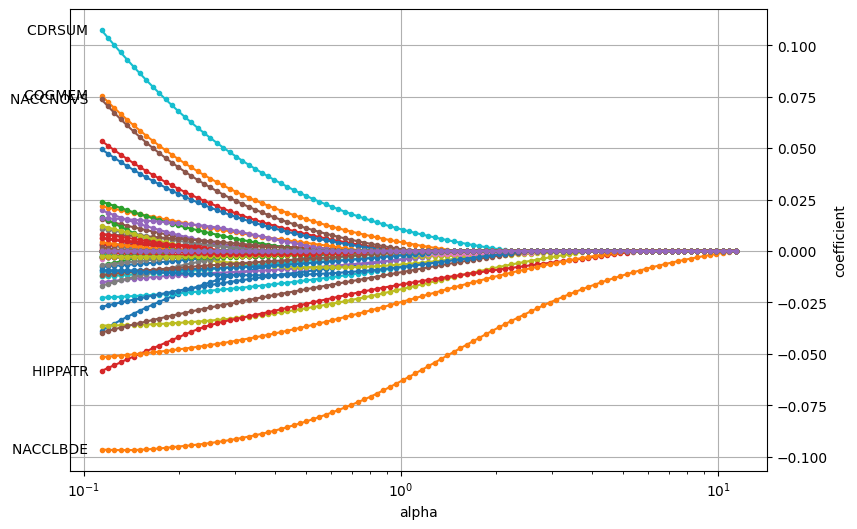

In [81]:
lasso_feature_importance_1 = cox_lasso_fs(x1_train, y1_train)
lasso_feature_importance_1 = lasso_feature_importance_1.iloc[:top_features_n_per_group] * 100
lasso_feature_importance_1

,importance,importance_abs
NACCNOVS,23.991543,23.991543
NACCDIED,13.602359,13.602359
SEX,-7.696594,7.696594
CDRSUM,5.616492,5.616492
WHODIDDX,2.672334,2.672334
OTHPSYIF,2.462153,2.462153
DYSILLIF,-2.383857,2.383857
CDRGLOB,2.380476,2.380476
FTD,-2.320543,2.320543
MEMORY,2.284688,2.284688


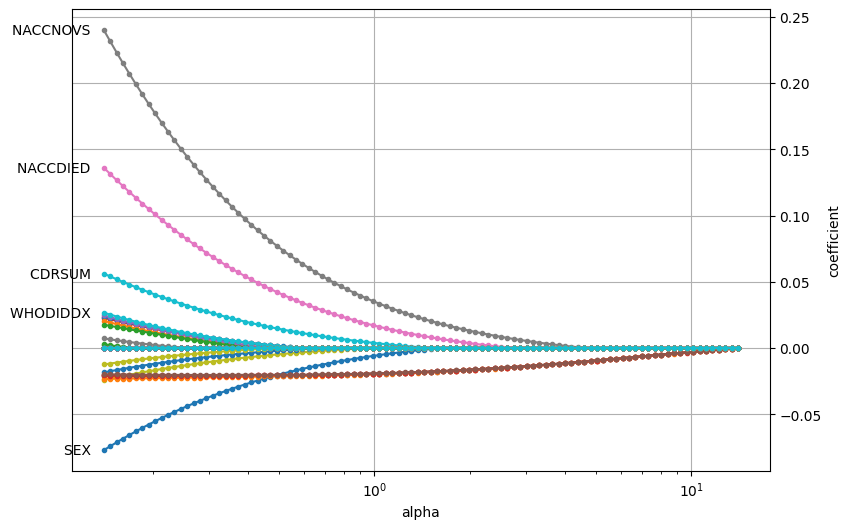

In [82]:
lasso_feature_importance_2 = cox_lasso_fs(x2_train, y2_train)
lasso_feature_importance_2 = lasso_feature_importance_2.iloc[:top_features_n_per_group] * 100
lasso_feature_importance_2

Overlaped features for 2 groups

In [83]:
lasso_overlap, lasso_union, lasso_unique1, lasso_unique2, lasso_gr_1, lasso_gr_2 = get_overlaped_and_and_unique_features(lasso_feature_importance_1, lasso_feature_importance_2)

In [84]:
lasso_overlap

{'CDRGLOB',
 'CDRSUM',
 'MEMORY',
 'NACCDIED',
 'NACCLBDE',
 'NACCNOVS',
 'NACCPPA',
 'OTHPSYIF',
 'SEX'}

In [85]:
lasso_unique1

{'ALCDEMIF',
 'AMYLCSF',
 'COGMEM',
 'CVDIF',
 'DEPIF',
 'DEPTREAT',
 'FDGAD',
 'HIPPATR',
 'IMAGMICH',
 'JUDGMENT',
 'TPETFTLD'}

In [86]:
lasso_unique2

{'ALCDEM',
 'COGOTHIF',
 'DEP',
 'DYSILLIF',
 'FTD',
 'MEDSIF',
 'PPAPH',
 'STROKE',
 'STROKIF',
 'VASC',
 'WHODIDDX'}

In [87]:
lasso_union

{'ALCDEM',
 'ALCDEMIF',
 'AMYLCSF',
 'CDRGLOB',
 'CDRSUM',
 'COGMEM',
 'COGOTHIF',
 'CVDIF',
 'DEP',
 'DEPIF',
 'DEPTREAT',
 'DYSILLIF',
 'FDGAD',
 'FTD',
 'HIPPATR',
 'IMAGMICH',
 'JUDGMENT',
 'MEDSIF',
 'MEMORY',
 'NACCDIED',
 'NACCLBDE',
 'NACCNOVS',
 'NACCPPA',
 'OTHPSYIF',
 'PPAPH',
 'SEX',
 'STROKE',
 'STROKIF',
 'TPETFTLD',
 'VASC',
 'WHODIDDX'}

In [88]:
final_features = lasso_union.intersection(rsf_union)

In [89]:
required_features = ["RACE", 'EDUC', 'SEX', 'NACCGDS', "SMOKYRS", "ALCOHOL", "NACCBMI", "CSFTAU"]

In [90]:
def select_final_features(features1, features2):
  return features1.union(features2)

rsf_final_fetures = select_final_features(rsf_union, set(required_features))
lasso_final_features = select_final_features(lasso_union, set(required_features))

In [91]:
# plt.figure(figsize=(20, 20))
# sns.heatmap(nacc_df[lasso_gr_1].corr() > 0.7)
# plt.xticks(rotation=45, fontsize=5)
# plt.yticks(fontsize=6)
# plt.show()

The further analysis will be provided on the next features:
Common (from articles): 'AMYLCSF', 'CSFTAU', 'FDGFTLD', 'SEX', 'EDUC', 'NACCAGE'
Feature selected: 'ANIMALS', 'COGSTAT', 'NACCAGEB', 'VEG', 'VISITYR', 'DEPTREAT', 'IMAGEWMH', 'NACCGDS', 'NACCLBDE', 'VISITMO' 'HEIGHT', 'NACCAMD', 'NACCPPA', 'NACCREFR', 'SMOKYRS'

Both feature selection methods (RSF and Cox Lasso) chose next common features:
'ANIMALS', 'COGSTAT', 'HEIGHT', 'NACCAGEB', 'VEG', 'NACCAMD', 'SMOKYRS', 'VISITYR'


In [92]:
selected_features = lasso_final_features

In [93]:
eda_df = nacc_df_grouped_copy.copy()
eda_df = eda_df[list(selected_features) + ['TIME', 'EVENT_MCI', 'group']]
eda_df.head()

,ALCDEM,ALCDEMIF,DEPTREAT,CVDIF,EDUC,JUDGMENT,CDRSUM,PPAPH,STROKE,NACCBMI,...,MEDSIF,AMYLCSF,DEPIF,NACCLBDE,NACCGDS,ALCOHOL,CSFTAU,TIME,EVENT_MCI,group
0,0,8,8.0,8.0,12.0,0.0,0.0,NaN,NaN,19.0,...,8,8.0,8,8,1.0,0.0,8.0,1.806982,0,1
1,0,8,8.0,8.0,14.0,0.0,0.0,NaN,NaN,25.1,...,8,8.0,8,8,0.0,0.0,8.0,1.108830,0,1
2,0,8,8.0,8.0,18.0,0.0,0.0,NaN,NaN,24.4,...,8,8.0,8,8,2.0,0.0,8.0,1.084189,0,1
3,0,8,8.0,8.0,13.0,0.0,0.0,NaN,NaN,32.6,...,8,8.0,8,8,1.0,0.0,8.0,1.527721,0,1
4,0,8,8.0,8.0,18.0,0.0,0.0,NaN,NaN,30.0,...,8,8.0,8,8,1.0,0.0,8.0,1.086927,0,1


In [94]:
eda_df.shape

(16716, 41)

In [95]:
cols_to_keep_nan = group_1_columns + group_2_columns
cols_for_complete_case = [c for c in eda_df.columns if c not in cols_to_keep_nan]
len(cols_for_complete_case)

27

In [96]:
eda_df.dropna(subset=cols_for_complete_case, inplace=True)
eda_df.shape

(14664, 41)

In [105]:
eda_gr_1 = eda_df.copy()[lasso_gr_1 + ['TIME', 'EVENT_MCI', 'group']]
x1_mask = eda_gr_1['group'] == 1
eda_gr_1 = eda_gr_1[x1_mask].dropna(axis=1)
eda_gr_1 = eda_gr_1.drop(columns=['group'])

eda_gr_2 = eda_df.copy()[lasso_gr_2 + ['TIME', 'EVENT_MCI', 'group']]
x2_mask = eda_gr_2['group'] == 2
eda_gr_2 = eda_gr_2[x2_mask].dropna(axis=1)
eda_gr_2 = eda_gr_2.drop(columns=['group'])

In [98]:
eda_gr_1.shape, eda_gr_2.shape

((5769, 22), (8895, 22))

In [99]:
from matplotlib import pyplot as plt
from lifelines import CoxPHFitter
import numpy as np
import pandas as pd


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

[[<Axes: xlabel='rank-transformed time\n(p=0.9977)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9981)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9968)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9972)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9979)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9983)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9999)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9999)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9997)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9997)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9986)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9988)'>],
 [<Axes: xlabel='rank-transformed time\n(p=1.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9997)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9986)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9988)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9978)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9980)'>],
 [<Axes: xlabel='rank-transformed tim

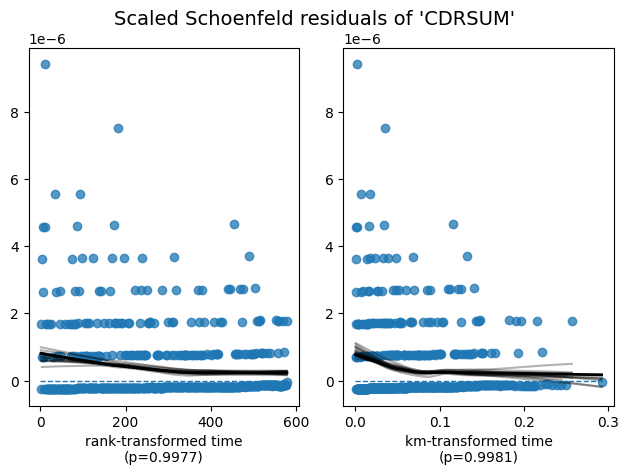

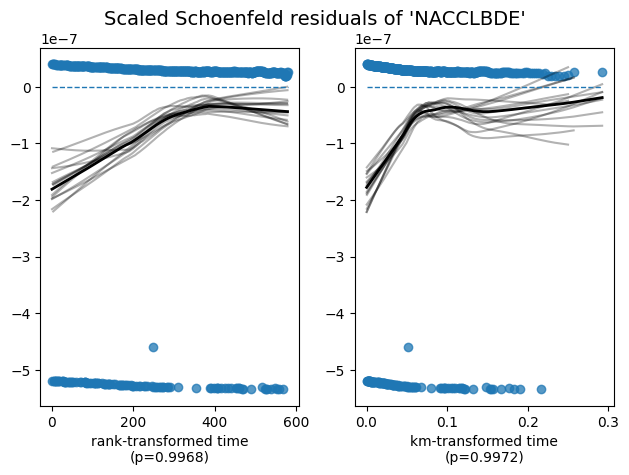

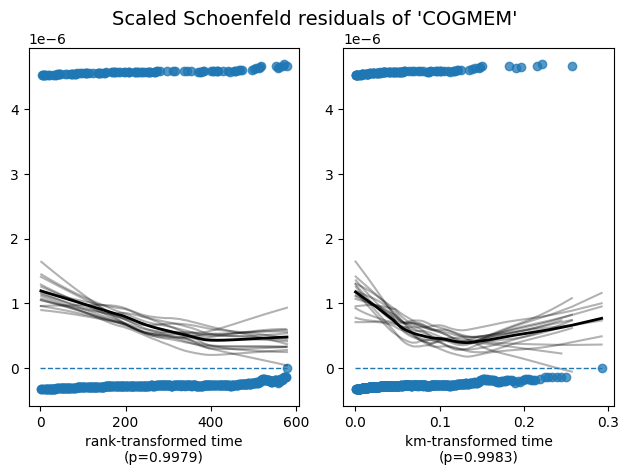

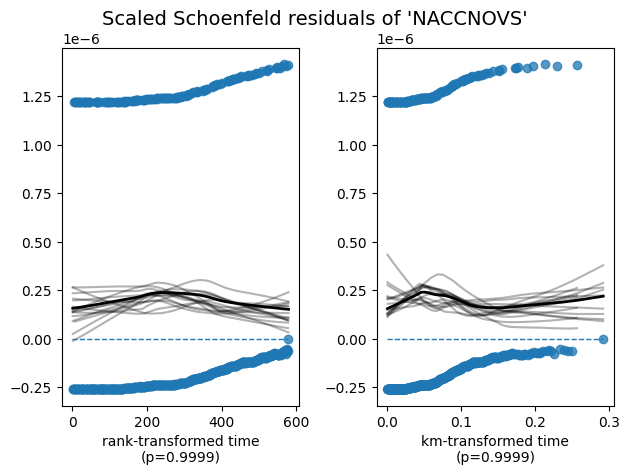

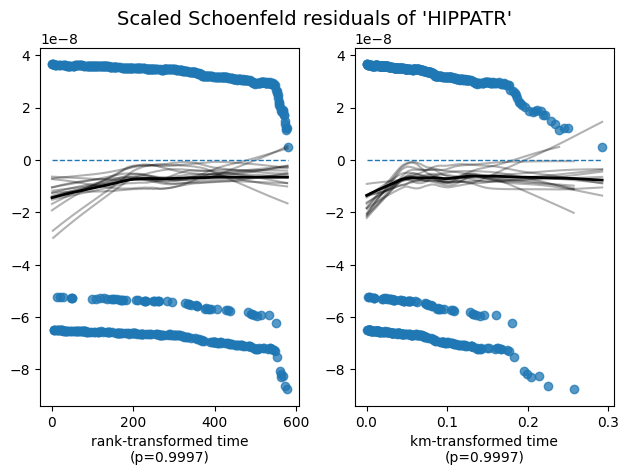

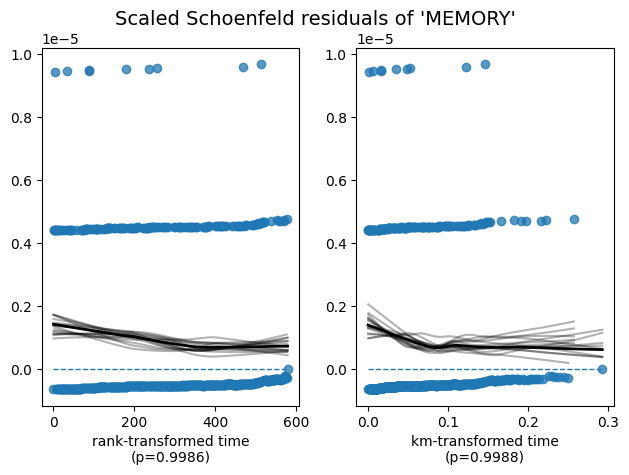

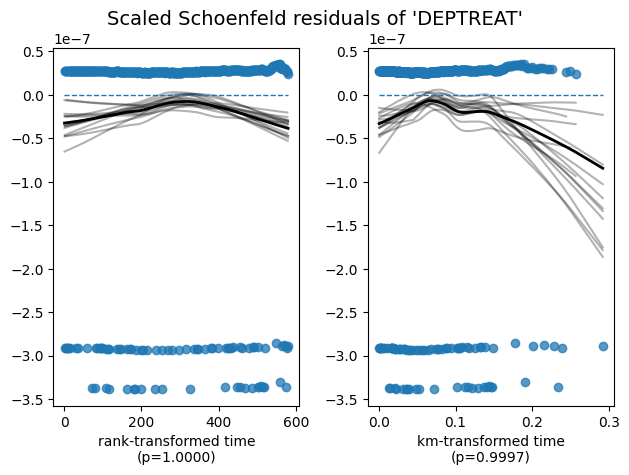

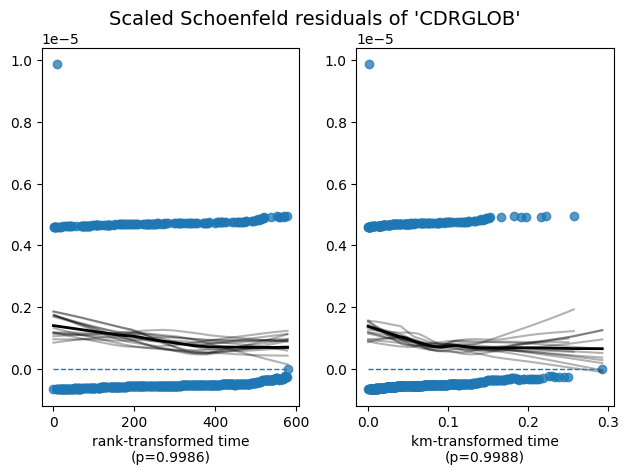

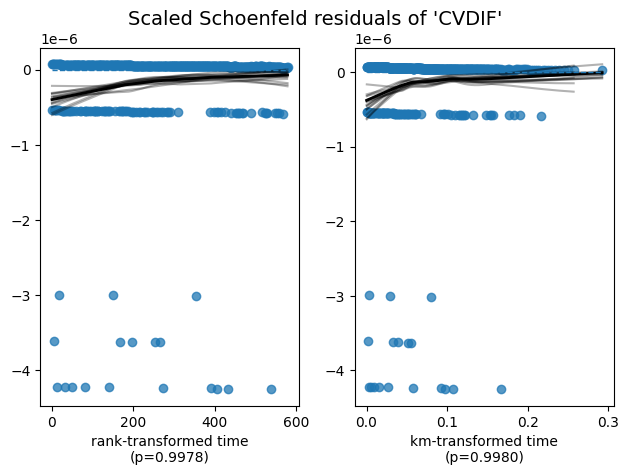

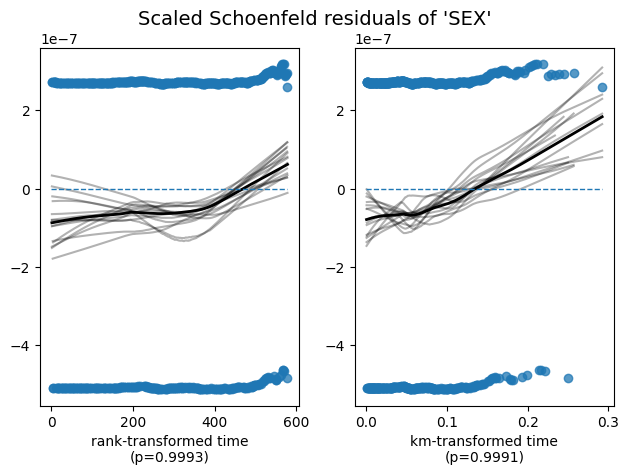

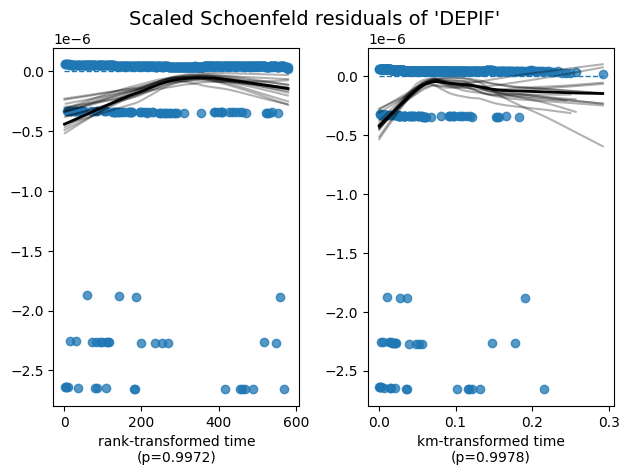

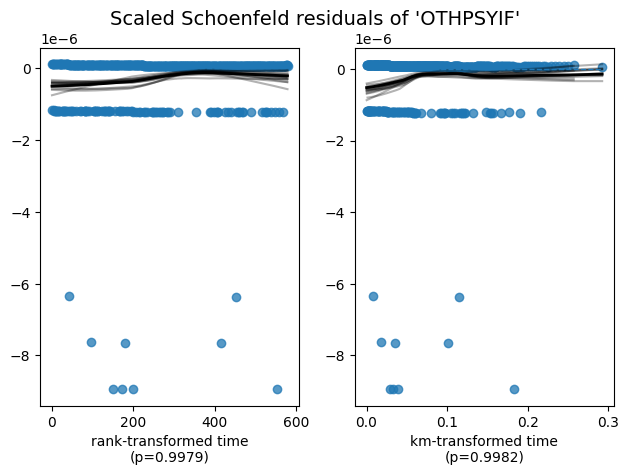

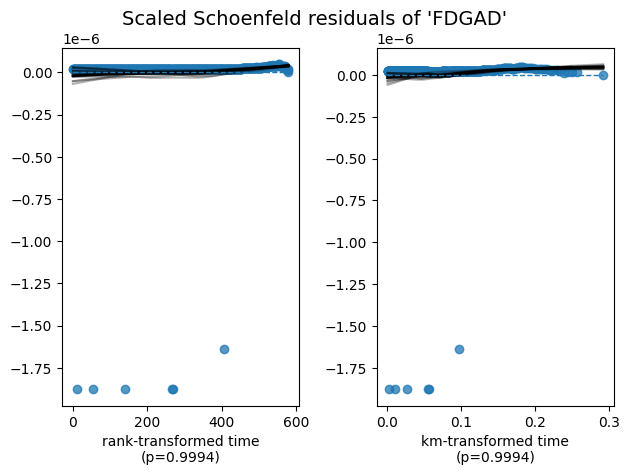

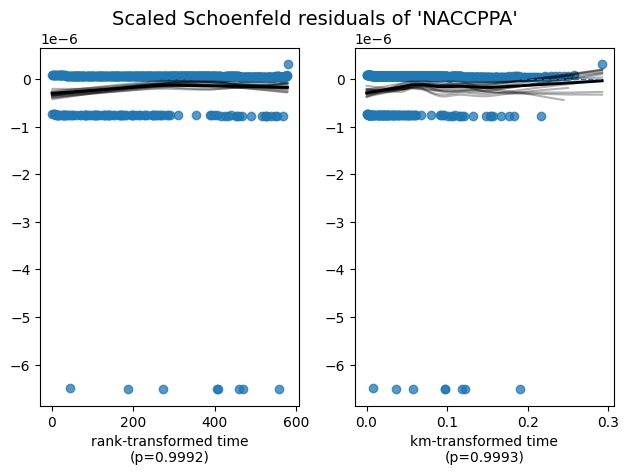

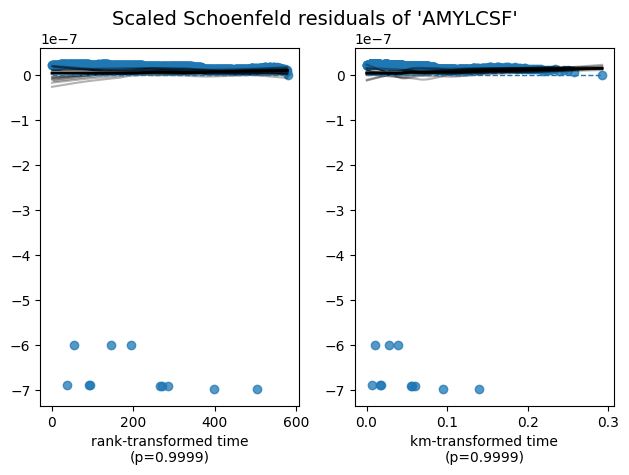

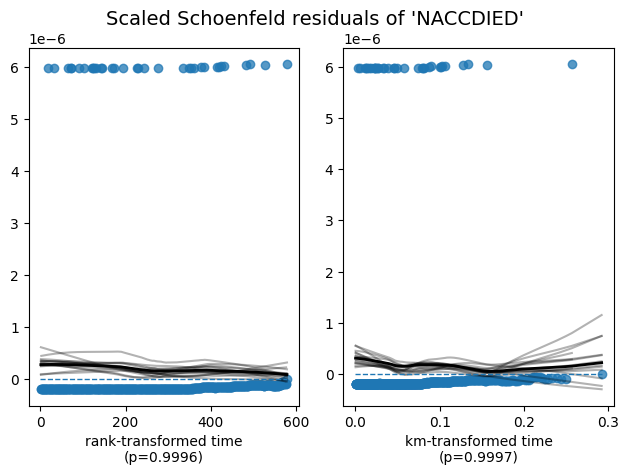

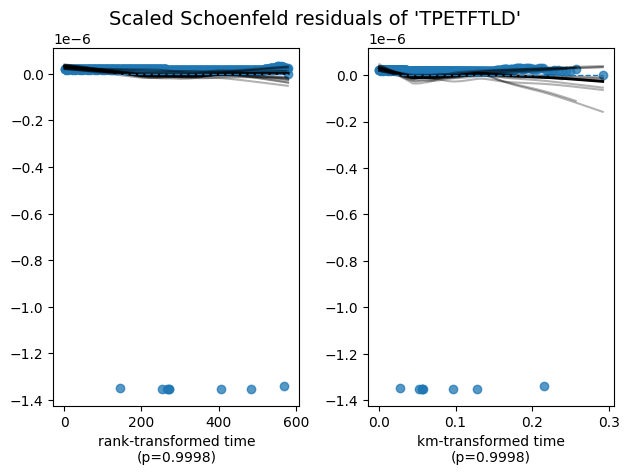

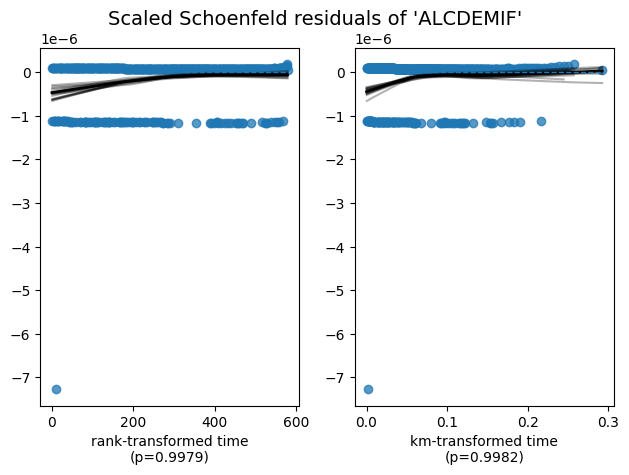

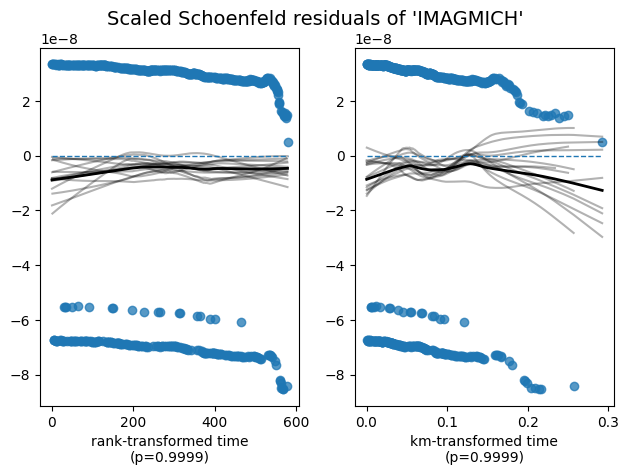

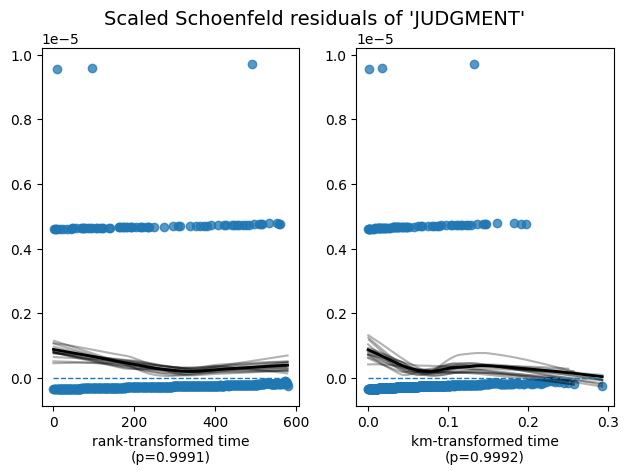

In [106]:
cph = CoxPHFitter(penalizer=0.1, l1_ratio=1.0)
cph.fit(eda_gr_1, duration_col='TIME', event_col='EVENT_MCI')
cph.check_assumptions(eda_gr_1, p_value_threshold=0.05, show_plots=True)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

[[<Axes: xlabel='rank-transformed time\n(p=0.9546)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3163)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9992)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9995)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9987)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9985)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9964)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9969)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9996)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9995)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9976)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9982)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9981)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9981)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9957)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9961)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9957)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9963)'>],
 [<Axes: xlabel='rank-transformed tim

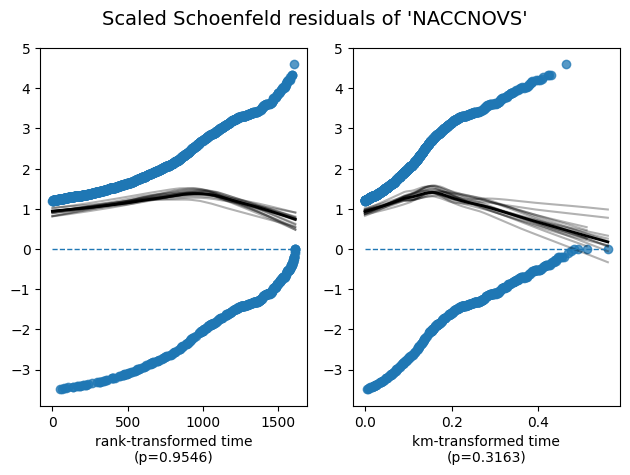

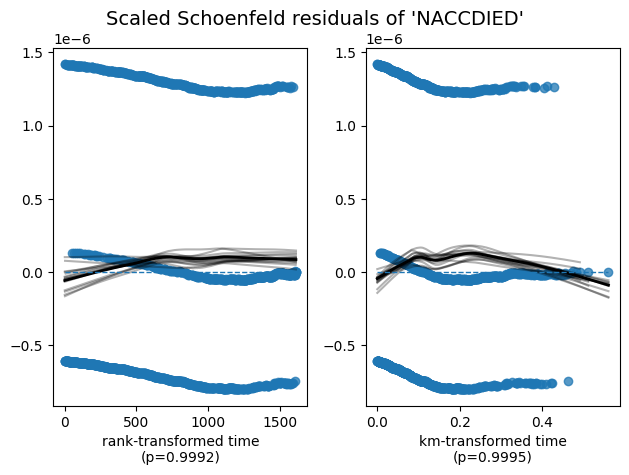

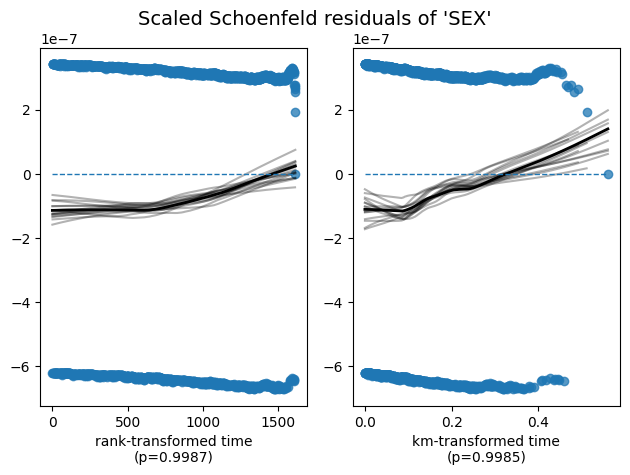

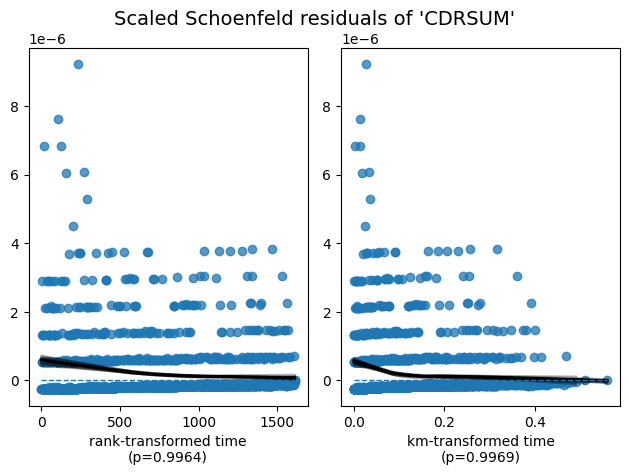

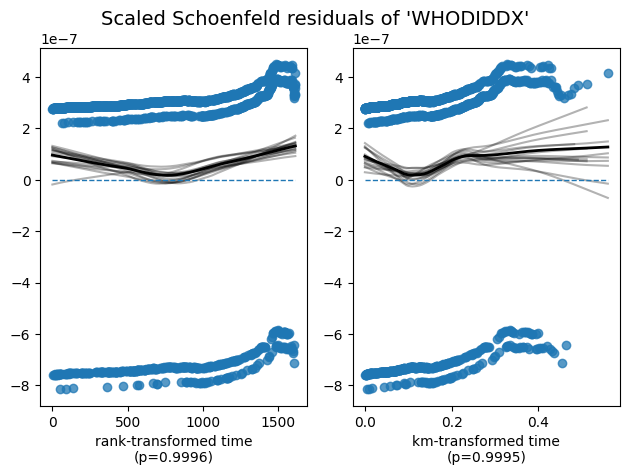

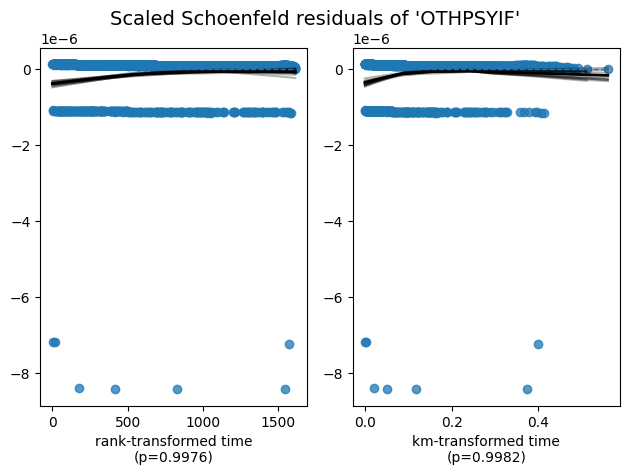

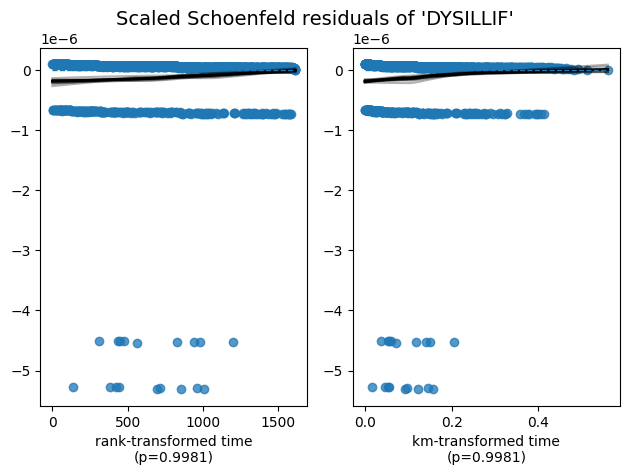

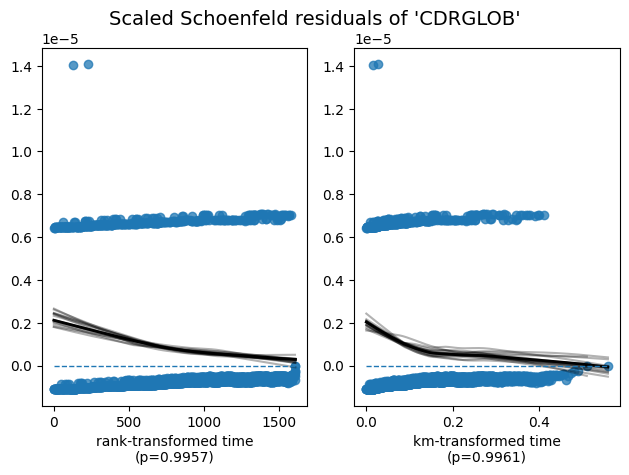

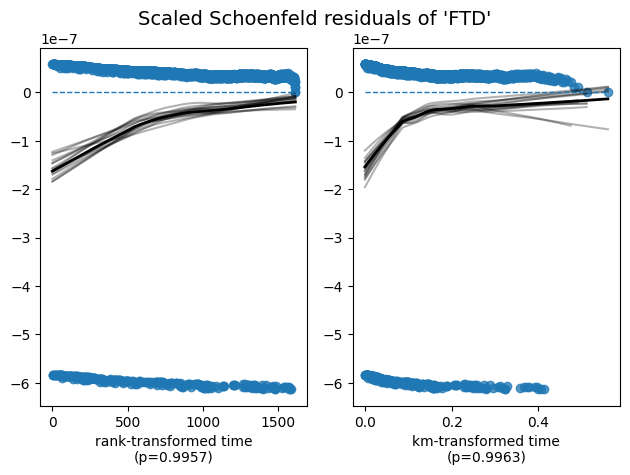

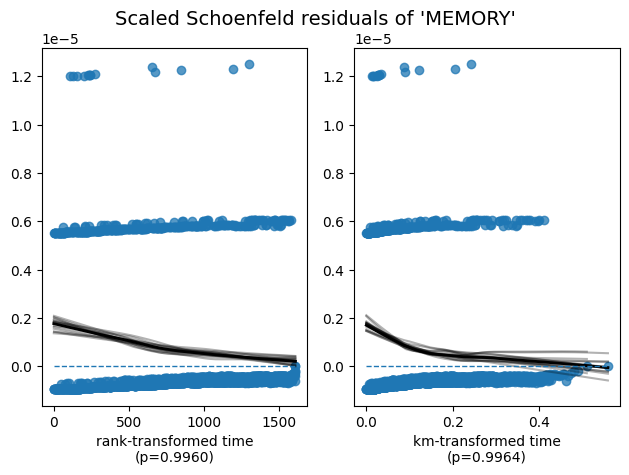

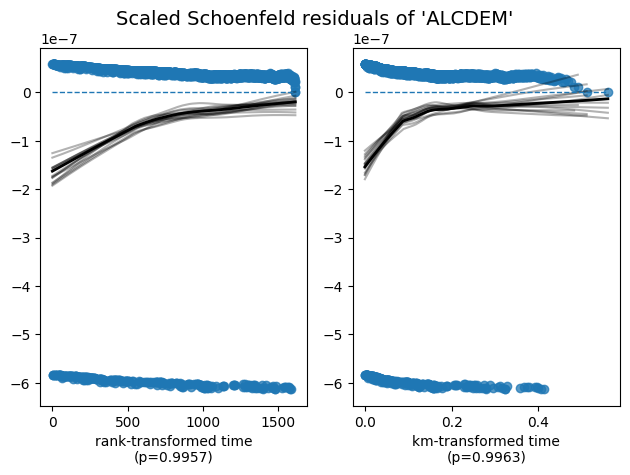

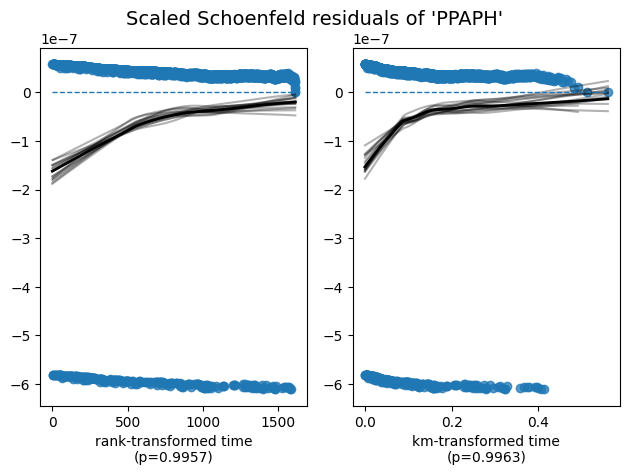

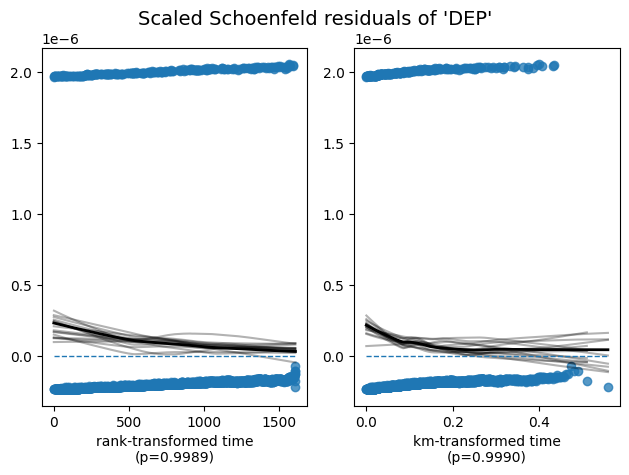

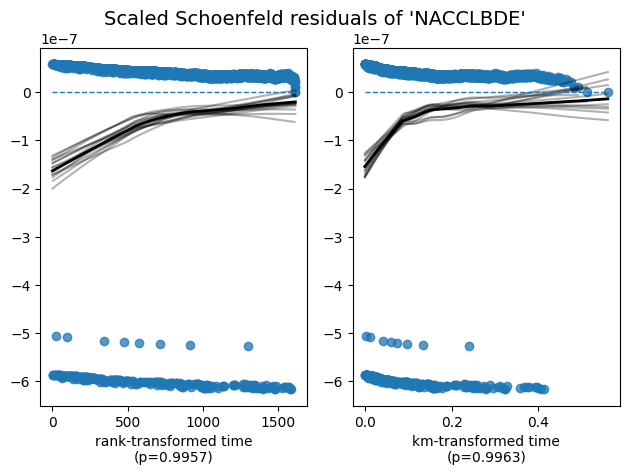

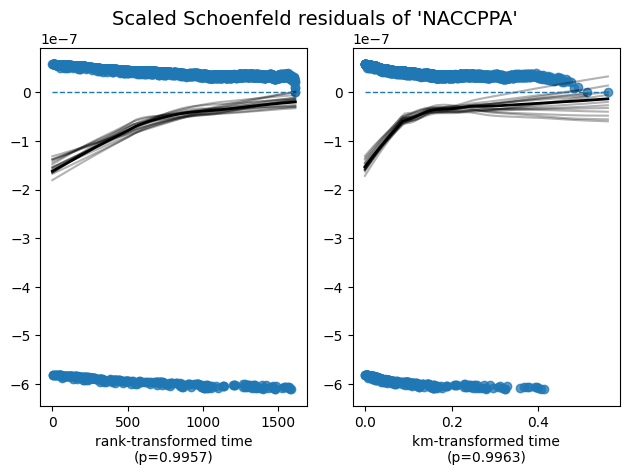

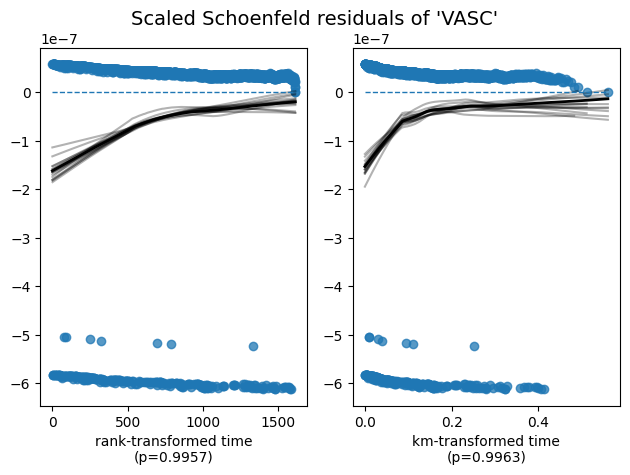

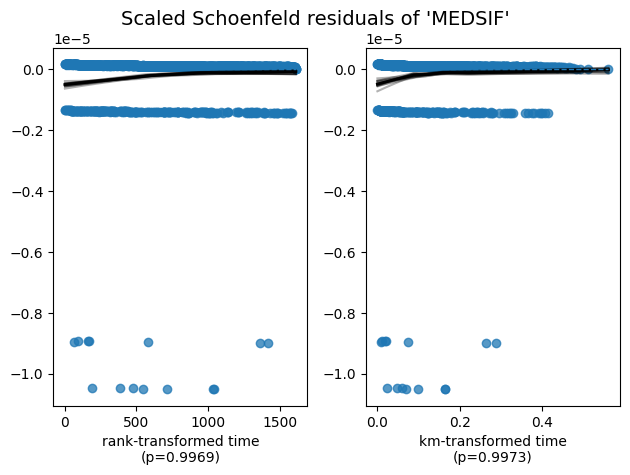

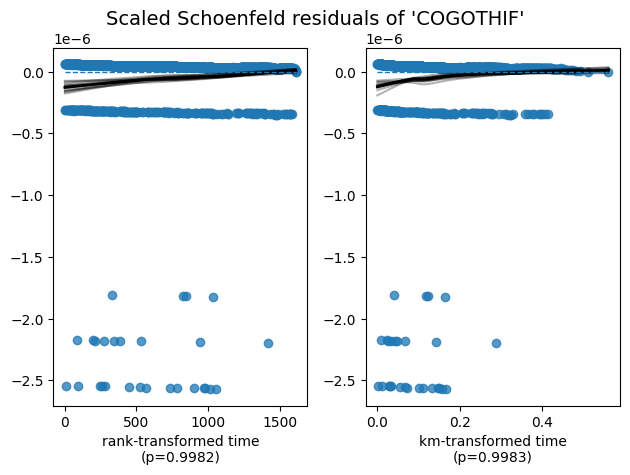

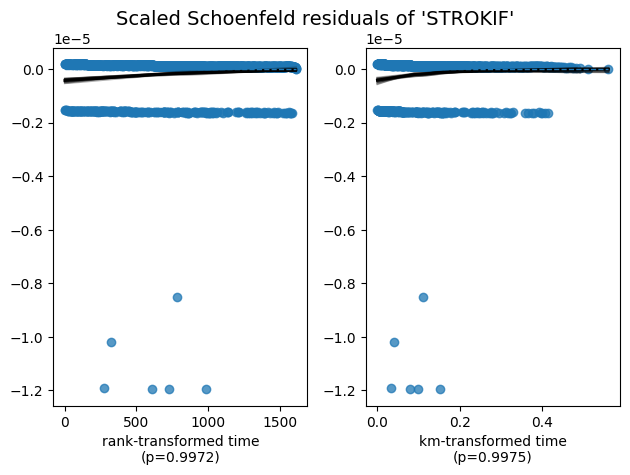

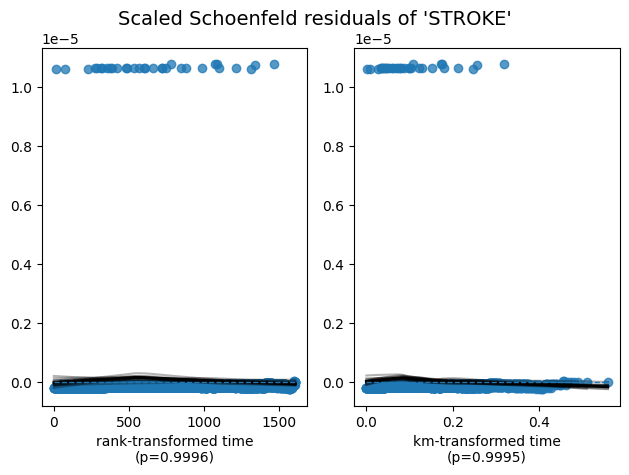

In [101]:
cph = CoxPHFitter(penalizer=0.1, l1_ratio=1.0)
cph.fit(eda_gr_2, duration_col='TIME', event_col='EVENT_MCI')
cph.check_assumptions(eda_gr_2, p_value_threshold=0.05, show_plots=True)